In [162]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from kneed import KneeLocator
import tkinter as tk
from tkinter import ttk, messagebox
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
from matplotlib.figure import Figure
import warnings
warnings.filterwarnings("ignore")

In [163]:
file_path = 'Customer_Data.csv'
data = pd.read_csv(file_path)

In [164]:
data

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,C19186,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.500000,6
8946,C19187,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,275.861322,NaN,0.000000,6
8947,C19188,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.250000,6
8948,C19189,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.250000,6


In [165]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [166]:
data.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


In [167]:
for col in data:
    print(f"{col}: {data[col].unique()}\n")

CUST_ID: ['C10001' 'C10002' 'C10003' ... 'C19188' 'C19189' 'C19190']

BALANCE: [  40.900749 3202.467416 2495.148862 ...   23.398673   13.457564
  372.708075]

BALANCE_FREQUENCY: [0.818182 0.909091 1.       0.636364 0.545455 0.875    0.454545 0.727273
 0.5      0.888889 0.090909 0.272727 0.363636 0.       0.666667 0.75
 0.857143 0.181818 0.333333 0.6      0.3      0.125    0.9      0.833333
 0.8      0.2      0.777778 0.555556 0.25     0.142857 0.571429 0.4
 0.444444 0.714286 0.222222 0.1      0.625    0.428571 0.111111 0.285714
 0.7      0.375    0.166667]

PURCHASES: [  95.4     0.    773.17 ...  291.12  144.4  1093.25]

ONEOFF_PURCHASES: [   0.    773.17 1499.   ...  734.4  1012.73 1093.25]

INSTALLMENTS_PURCHASES: [  95.4     0.   1333.28 ...  113.28  291.12  144.4 ]

CASH_ADVANCE: [   0.       6442.945483  205.788017 ... 8555.409326   36.558778
  127.040008]

PURCHASES_FREQUENCY: [0.166667 0.       1.       0.083333 0.666667 0.333333 0.25     0.75
 0.5      0.416667 0.916667 0.5833

In [168]:
data.isnull().sum()

CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

In [169]:
null_percent = data["MINIMUM_PAYMENTS"].isnull().mean()*100
null_percent

np.float64(3.4972067039106145)

In [170]:
data = data.dropna(subset=["MINIMUM_PAYMENTS", "CREDIT_LIMIT"])

Droping all rows where MINIMUM_PAYMENTS or CREDIT_LIMIT is missing due to the fact that missing values are less than 5%

In [171]:
customer_id = data["CUST_ID"]
data = data.drop(columns=["CUST_ID"])

Saving CUST_ID in a separate variable and remove it from the dataset so it will not affect clustering

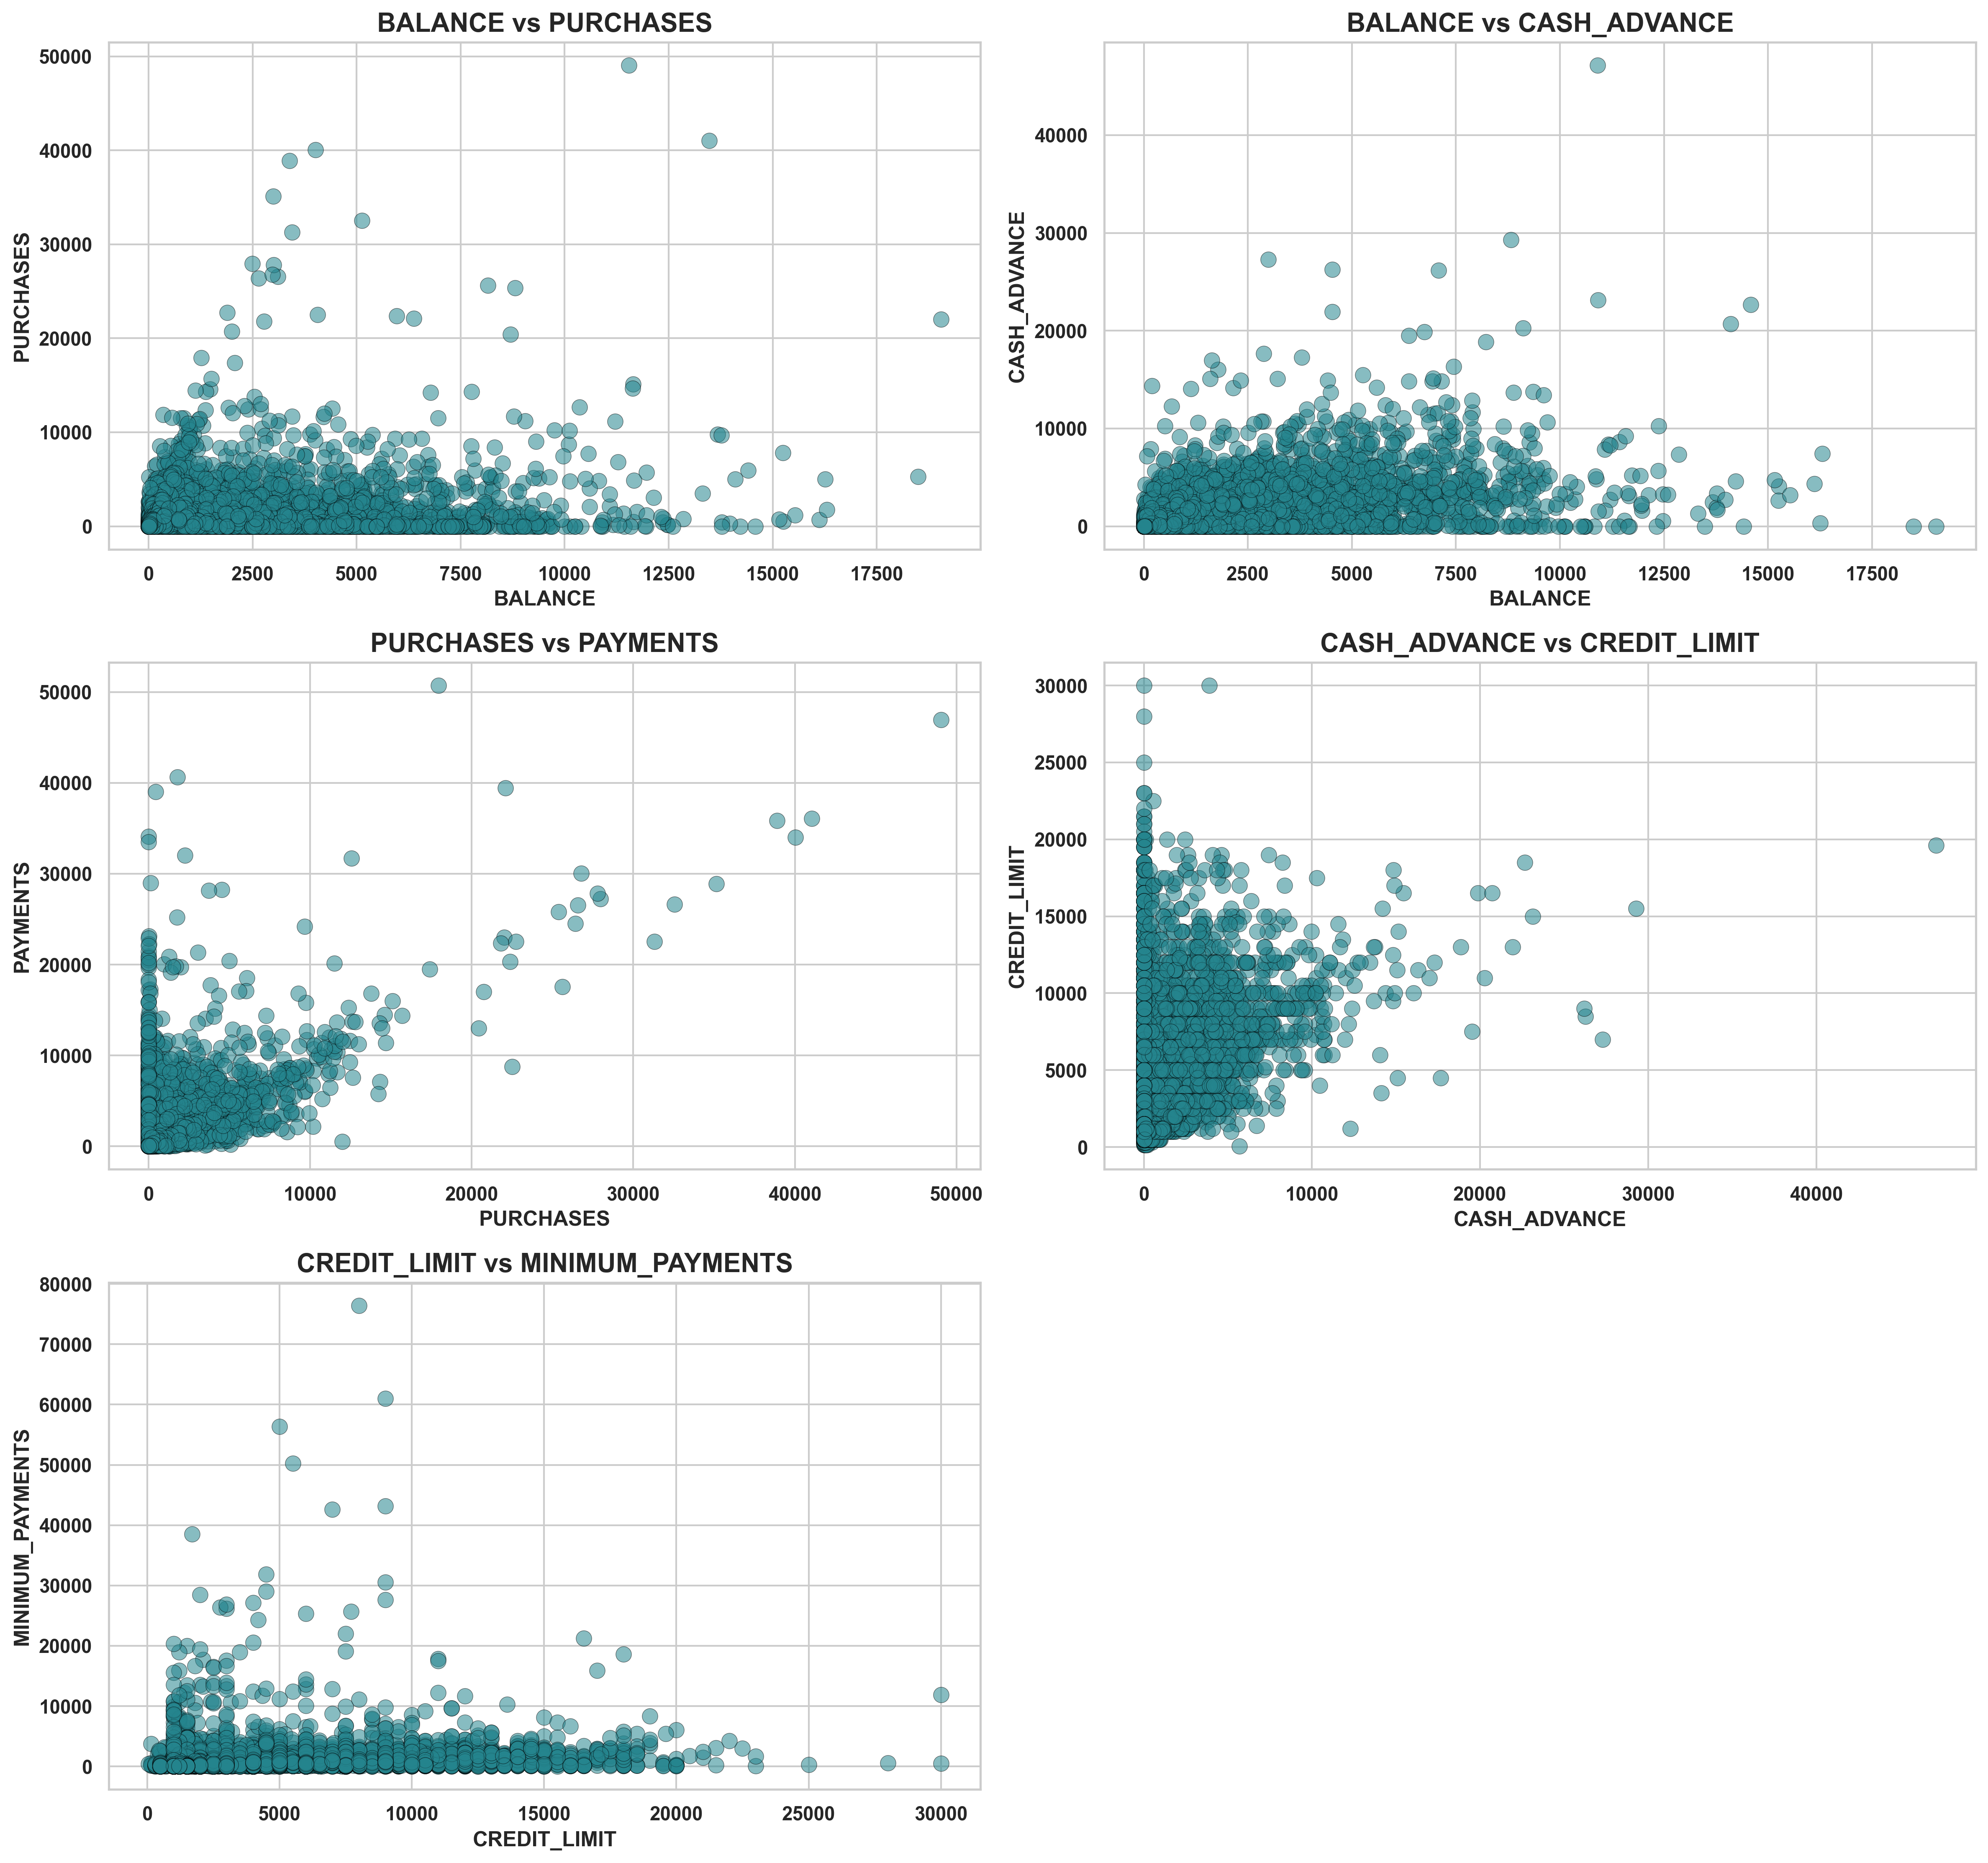

In [172]:
sns.set(style="whitegrid")
plt.rcParams.update({
    'figure.dpi': 300,
    'axes.labelsize': 13,
    'axes.titlesize': 15,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 10,
    'font.weight': 'bold',
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold'
})

pairs = [
    ('BALANCE', 'PURCHASES'),
    ('BALANCE', 'CASH_ADVANCE'),
    ('PURCHASES', 'PAYMENTS'),
    ('CASH_ADVANCE', 'CREDIT_LIMIT'),
    ('CREDIT_LIMIT', 'MINIMUM_PAYMENTS')
]

ncols = 2
nrows = (len(pairs) + 1) // ncols

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, nrows * 5))
axes = axes.flatten()

for idx, (ax, (x, y)) in enumerate(zip(axes, pairs)):
    sns.scatterplot(
        data=data,
        x=x, y=y,
        color=sns.color_palette("viridis", 10)[4],   
        alpha=0.55,
        edgecolor='black',
        linewidth=0.3,
        s=80,   
        ax=ax
    )
    
    ax.set_title(f"{x} vs {y}", fontweight='bold')
    ax.set_xlabel(x, fontsize=12, fontweight='bold')
    ax.set_ylabel(y, fontsize=12, fontweight='bold')

for j in range(len(pairs), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

Scatterplots were generated to visually inspect relationships between key financial features and check for any natural separation patterns before clustering

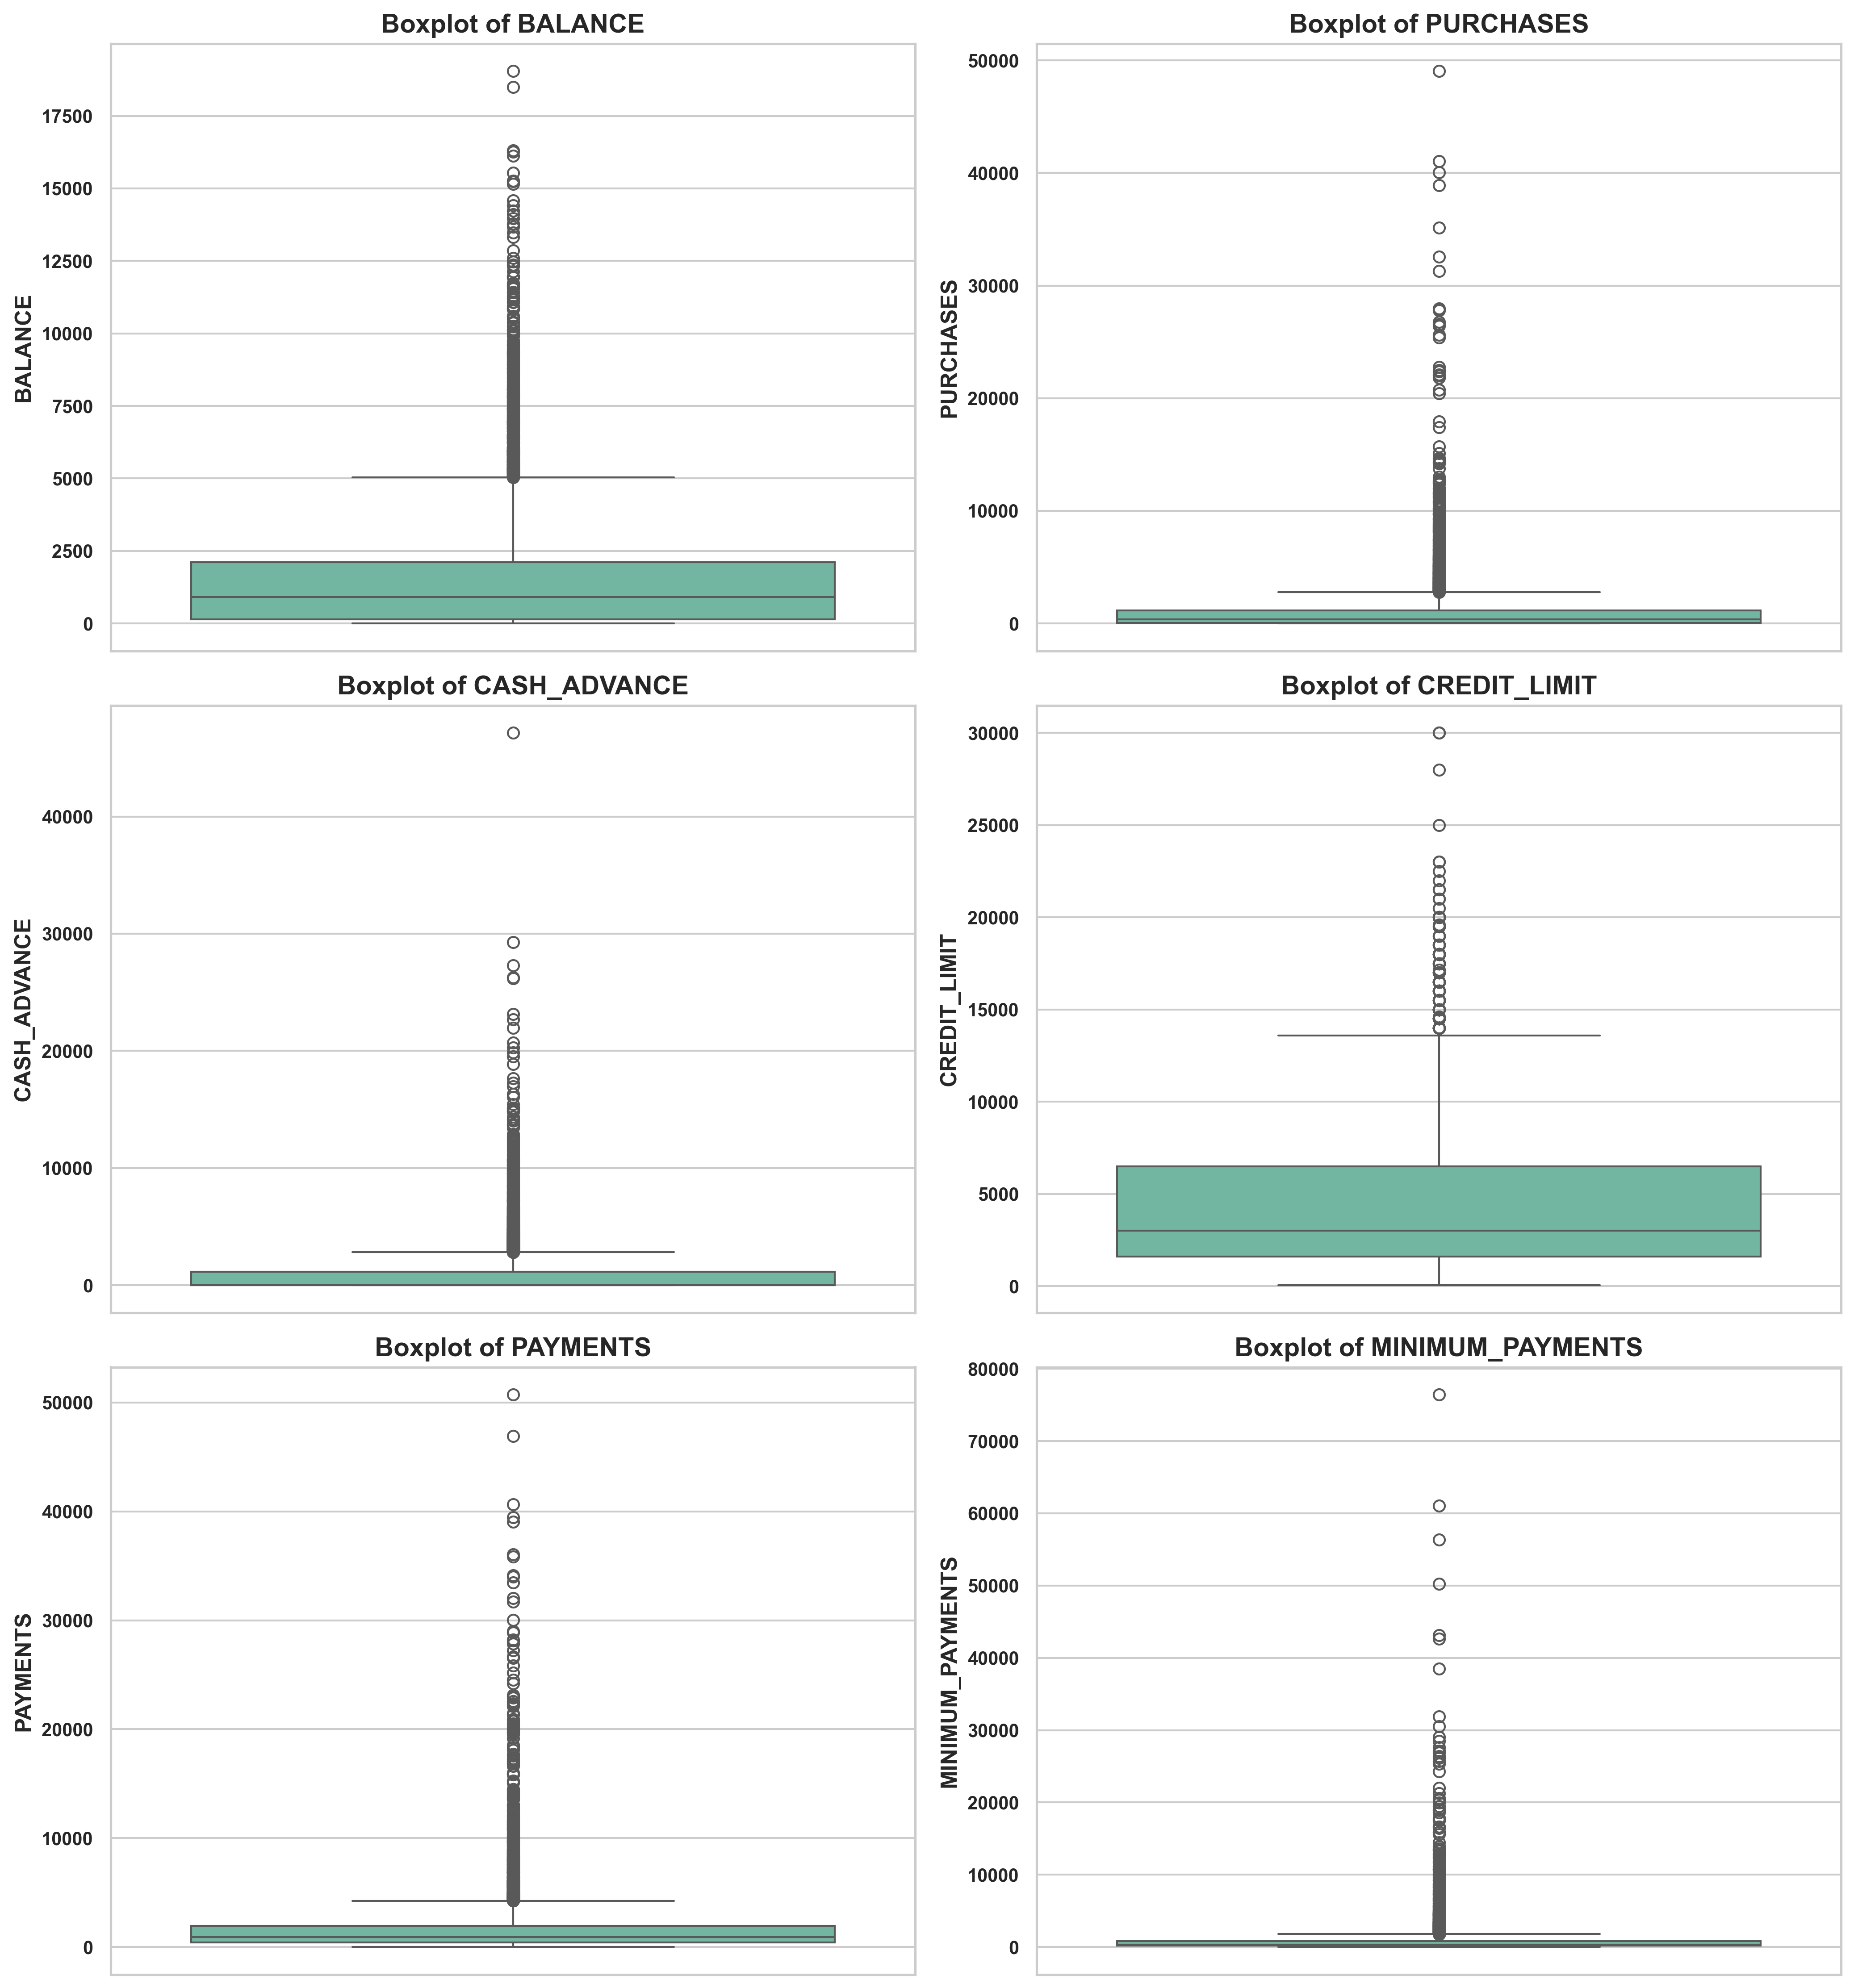

In [173]:
sns.set(style="whitegrid")
plt.rcParams.update({
    'figure.dpi': 300,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold'
})

features = [
    'BALANCE',
    'PURCHASES',
    'CASH_ADVANCE',
    'CREDIT_LIMIT',
    'PAYMENTS',
    'MINIMUM_PAYMENTS'
]

ncols = 2
nrows = (len(features) + 1) // ncols

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, nrows * 5))
axes = axes.flatten()

for idx, (ax, feat) in enumerate(zip(axes, features)):
    sns.boxplot(
        data=data,
        y=feat,
        ax=ax,
        color=sns.color_palette("Set2")[0]   
    )
    
    ax.set_title(f"Boxplot of {feat}")
    ax.set_xlabel("")
    ax.set_ylabel(feat)

for j in range(len(features), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

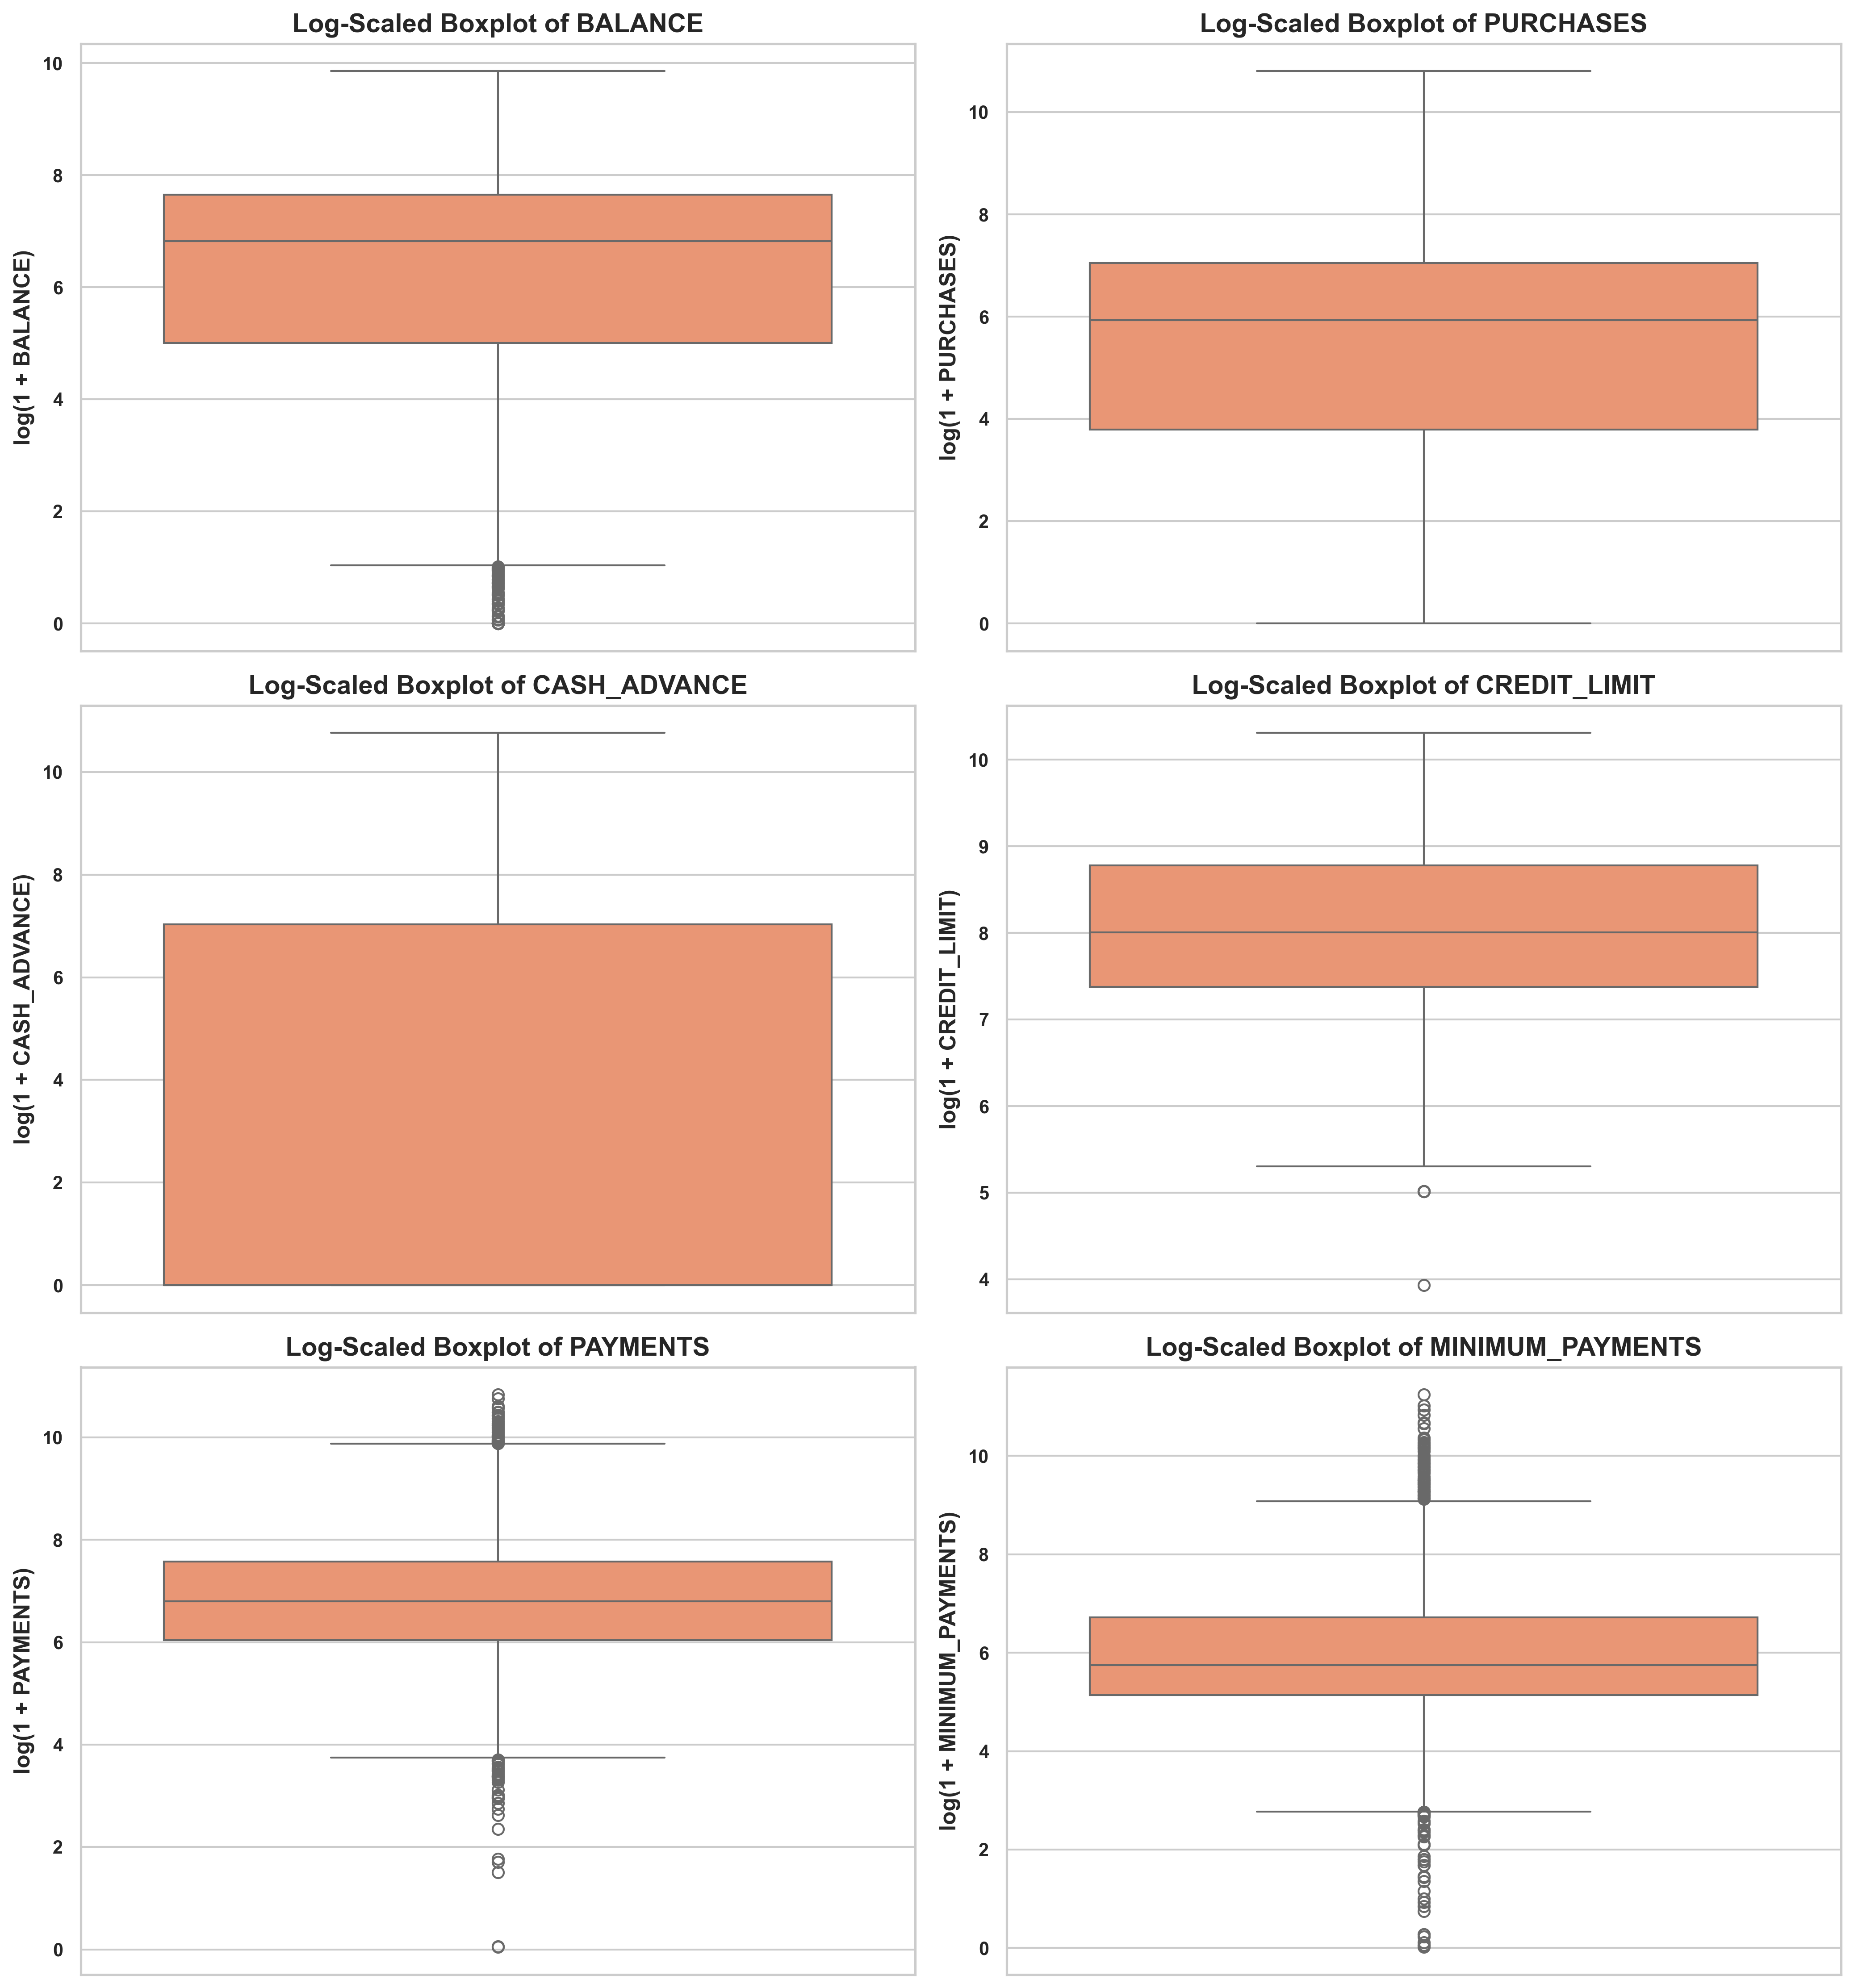

In [174]:
sns.set(style="whitegrid")
plt.rcParams.update({
    'figure.dpi': 300,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold'
})

features = [
    'BALANCE',
    'PURCHASES',
    'CASH_ADVANCE',
    'CREDIT_LIMIT',
    'PAYMENTS',
    'MINIMUM_PAYMENTS'
]

data_log = data.copy()
for col in features:
    data_log[col] = np.log1p(data_log[col])  

ncols = 2
nrows = (len(features) + 1) // ncols

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, nrows * 5))
axes = axes.flatten()

color = sns.color_palette("Set2")[1]

for ax, feat in zip(axes, features):
    sns.boxplot(
        data=data_log,
        y=feat,
        ax=ax,
        color=color
    )
    
    ax.set_title(f"Log-Scaled Boxplot of {feat}")
    ax.set_xlabel("")
    ax.set_ylabel(f"log(1 + {feat})")

for j in range(len(features), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

Due to the fact that financial variables were highly skewed so a log(1+x) transformation was applied to reduce skewness Log-transformed boxplots show more balanced distributions

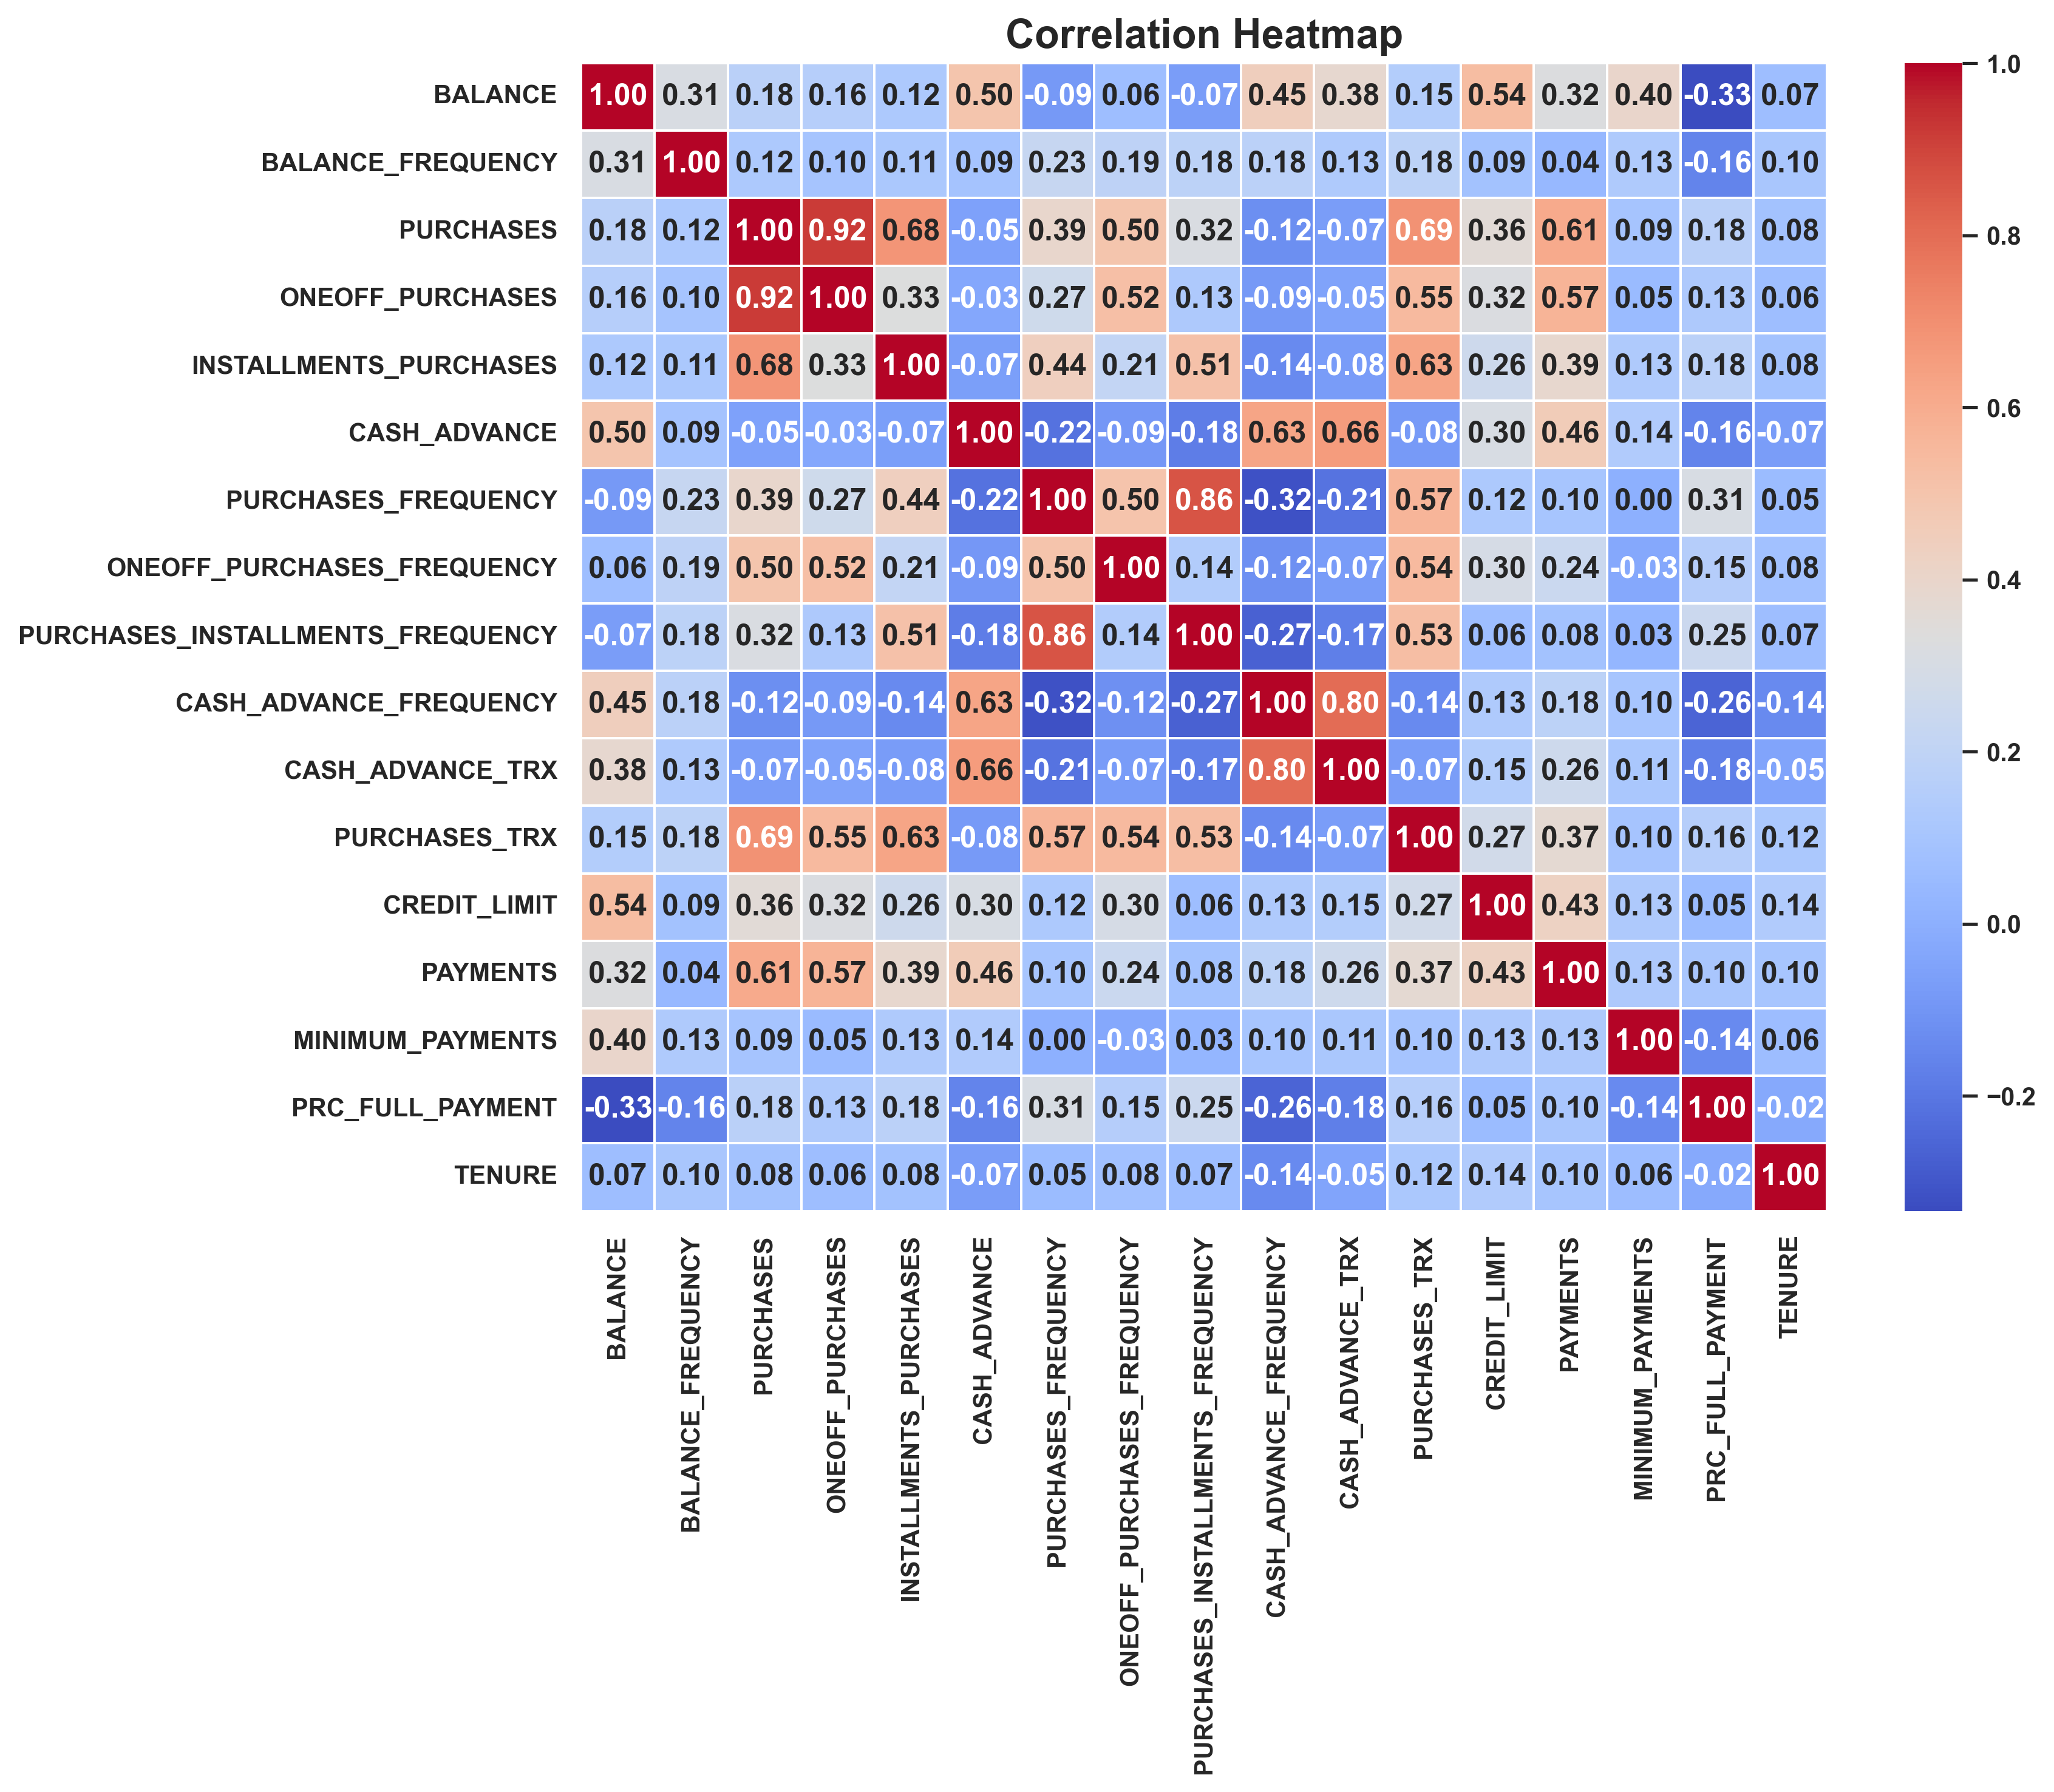

In [175]:
sns.set(style="whitegrid")
plt.rcParams.update({
    'figure.dpi': 300,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold'
})

corr = data.corr()

plt.figure(figsize=(12,10))
sns.heatmap(
    corr,
    cmap='coolwarm',
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

In [176]:
logic_noise = pd.DataFrame(columns=['column', 'index', 'value'])

conditions = {
    'BALANCE':                         lambda x: (x < 0),
    'PURCHASES':                       lambda x: (x < 0),
    'ONEOFF_PURCHASES':                lambda x: (x < 0),
    'INSTALLMENTS_PURCHASES':          lambda x: (x < 0),
    'CASH_ADVANCE':                    lambda x: (x < 0),
    'PAYMENTS':                        lambda x: (x < 0),
    'MINIMUM_PAYMENTS':                lambda x: (x < 0),
    'CREDIT_LIMIT':                    lambda x: (x <= 0),
    'BALANCE_FREQUENCY':               lambda x: (x < 0) | (x > 1),
    'PURCHASES_FREQUENCY':             lambda x: (x < 0) | (x > 1),
    'ONEOFF_PURCHASES_FREQUENCY':      lambda x: (x < 0) | (x > 1),
    'PURCHASES_INSTALLMENTS_FREQUENCY':lambda x: (x < 0) | (x > 1),
    'PRC_FULL_PAYMENT':                lambda x: (x < 0) | (x > 1),
    'CASH_ADVANCE_FREQUENCY':          lambda x: (x < 0) | (x > 2),
    'CASH_ADVANCE_TRX':                lambda x: (x < 0) | (x % 1 != 0),
    'PURCHASES_TRX':                   lambda x: (x < 0) | (x % 1 != 0),
    'TENURE':                          lambda x: (x <= 0) | (x % 1 != 0) | (x > 12),
}

for col, condition in conditions.items():
    if col in data.columns:
        mask = condition(data[col])
        if mask.sum() > 0:
            temp_df = pd.DataFrame({
                'column': col,
                'index': data[mask].index,
                'value': data.loc[mask, col].values
            })
            logic_noise = pd.concat([logic_noise, temp_df], ignore_index=True)

print("number of logic-based noisy values:", len(logic_noise))
print(logic_noise.head())

number of logic-based noisy values: 0
Empty DataFrame
Columns: [column, index, value]
Index: []


Defined logic based rules to detect logical noises

In [177]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

In [178]:
kmeans_set = {
    "init": "random",
    "n_init": 10,
    "max_iter": 300,
    "random_state": 42
}

results = []
k_range = range(2, 11)  

for k in k_range:
    kmeans = KMeans(n_clusters=k, **kmeans_set)
    kmeans.fit(scaled_data)
    
    inertia = kmeans.inertia_
    
    results.append({
        "k": k,
        "inertia": inertia
    })

df_kmeans = pd.DataFrame(results)
df_kmeans

,k,inertia
0,2,123281.788681
1,3,108086.190930
2,4,95646.372776
3,5,88346.258747
4,6,81699.121303
5,7,76441.942792
6,8,72366.284447
7,9,68272.682784
8,10,63817.806551


Elbow at k = 4


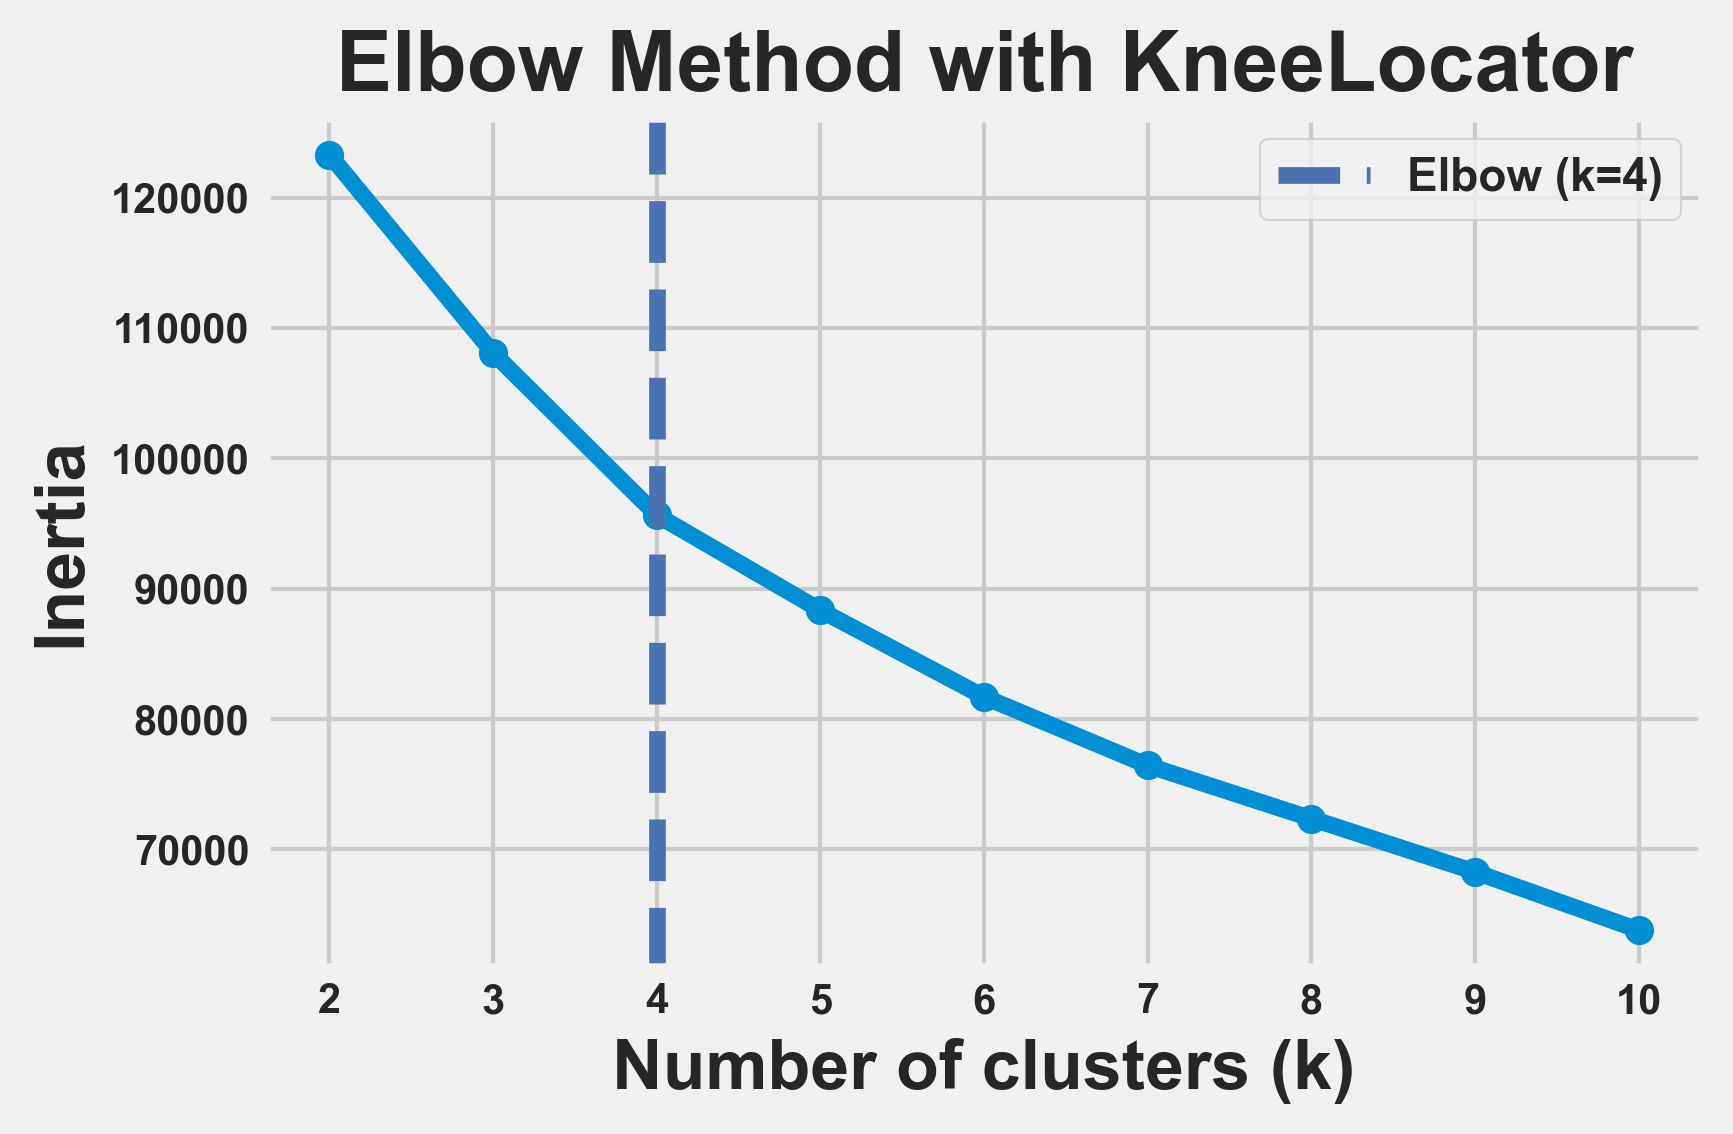

In [179]:
k_values = df_kmeans["k"].values
inertias = df_kmeans["inertia"].values

kl = KneeLocator(
    k_values,
    inertias,
    curve="convex",
    direction="decreasing"
)

print("Elbow at k =", kl.elbow)

plt.style.use("fivethirtyeight")
plt.figure(figsize=(6,4))
plt.plot(k_values, inertias, marker="o")
plt.xticks(k_values)
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method with KneeLocator")

if kl.elbow is not None:
    plt.axvline(x=kl.elbow, color="b", linestyle="--", label=f"Elbow (k={kl.elbow})")
    plt.legend()

plt.tight_layout()
plt.show()

In [180]:
k_values = df_kmeans["k"].values
inertias = df_kmeans["inertia"].values

kl = KneeLocator(
    k_values,
    inertias,
    curve="convex",
    direction="decreasing"
)

elbow_k = kl.elbow
print("Elbow at k =", elbow_k)

Elbow at k = 4


In [181]:
best_idx_overall = df_kmeans.index[df_kmeans["k"] == elbow_k][0]

def highlight_best_row_km(row):
    return ["background-color: orange" if row.name == best_idx_overall else "" 
            for _ in row]

df_kmeans_style = df_kmeans.style.apply(highlight_best_row_km, axis=1)
df_kmeans_style

,k,inertia
0,2,123281.788681
1,3,108086.190930
2,4,95646.372776
3,5,88346.258747
4,6,81699.121303
5,7,76441.942792
6,8,72366.284447
7,9,68272.682784
8,10,63817.806551


In [182]:
silhouette_coefficients = []

k_values = range(2, 11)   

for k in k_values:
    kmeans = KMeans(n_clusters=k, **kmeans_set)
    kmeans.fit(scaled_data)
    
    score = silhouette_score(scaled_data, kmeans.labels_)
    silhouette_coefficients.append(score)

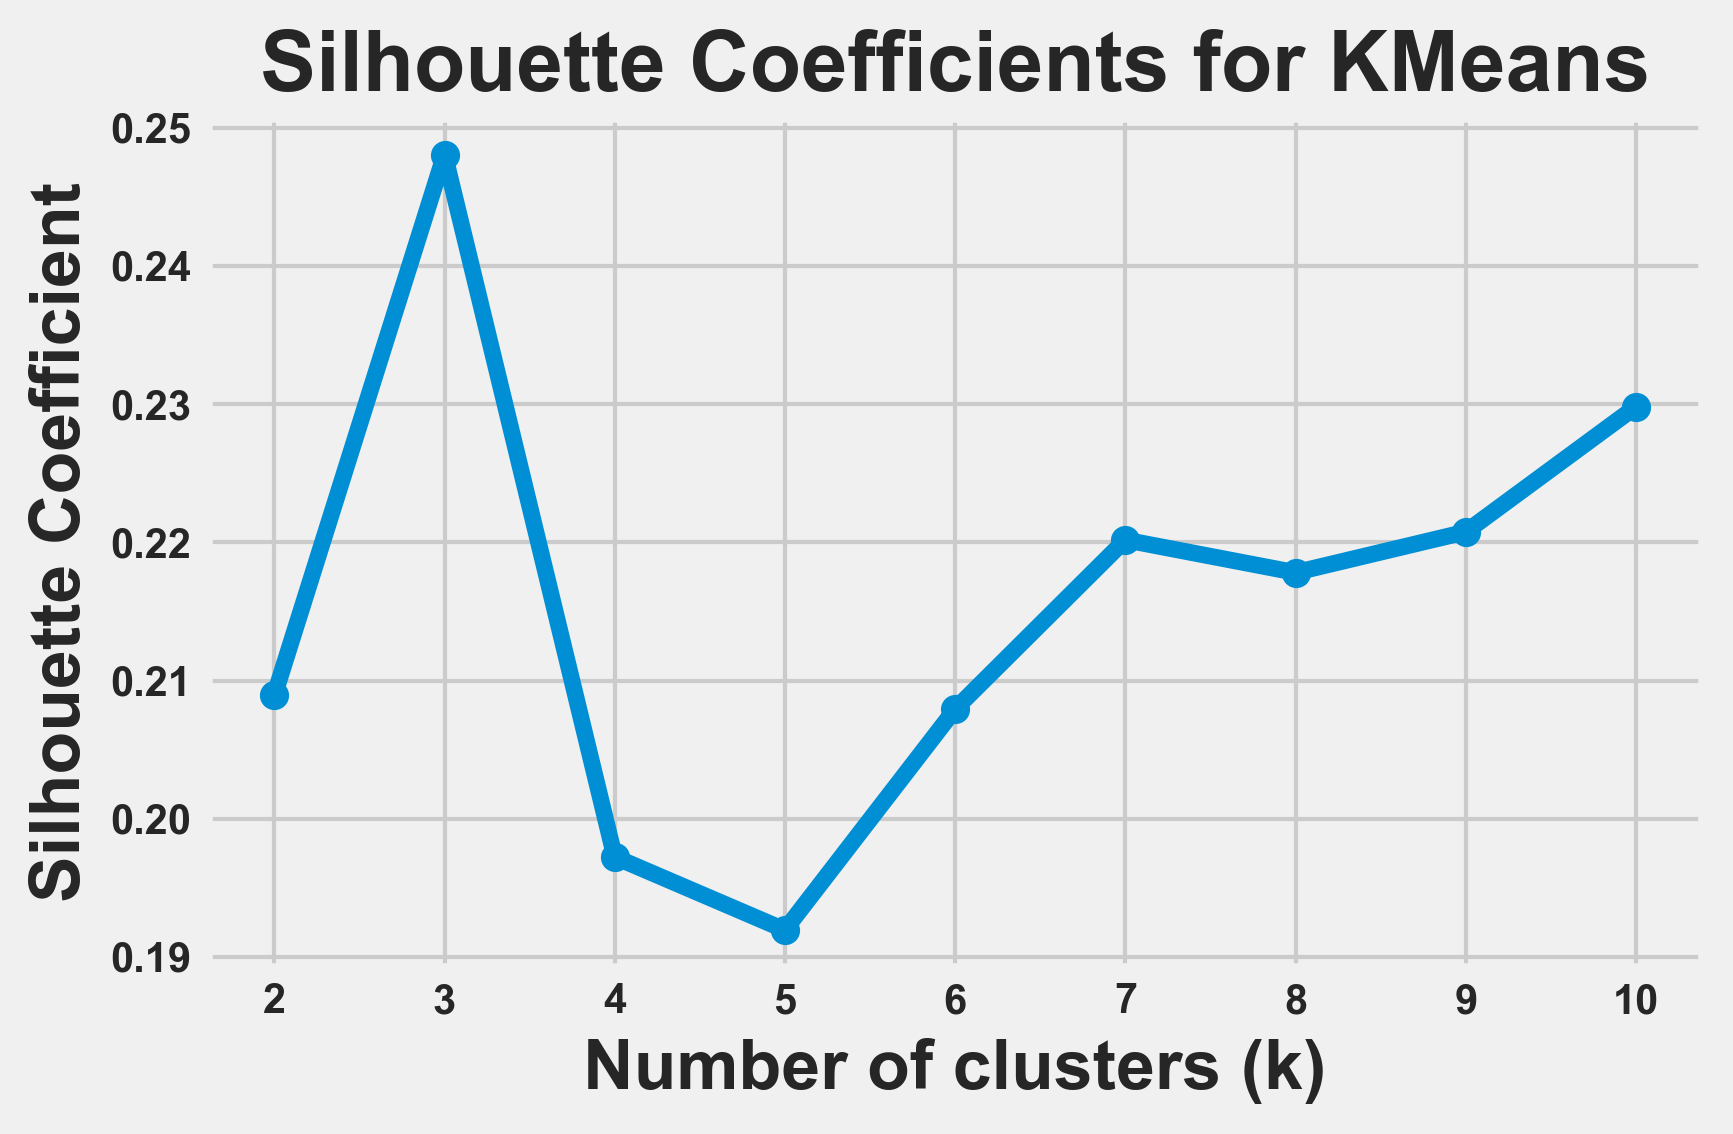

In [183]:
plt.style.use("fivethirtyeight")
plt.figure(figsize=(6,4))

plt.plot(list(k_values), silhouette_coefficients, marker="o")
plt.xticks(list(k_values))
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Coefficient")
plt.title("Silhouette Coefficients for KMeans")

plt.tight_layout()
plt.show()

In [184]:
inertia_list = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, **kmeans_set)
    kmeans.fit(scaled_data)
    inertia_list.append(kmeans.inertia_)

df_kmeans = pd.DataFrame({
    "k": list(k_values),
    "inertia": inertia_list,
    "silhouette": silhouette_coefficients
})

best_idx_overall = df_kmeans["silhouette"].idxmax()

def highlight_best_row_km(row):
    return ["background-color: orange" if row.name == best_idx_overall else "" 
            for _ in row]

df_kmeans_style = df_kmeans.style.apply(highlight_best_row_km, axis=1)

df_kmeans_style

,k,inertia,silhouette
0,2,123281.788681,0.208923
1,3,108086.190930,0.248045
2,4,95646.372776,0.197231
3,5,88346.258747,0.191951
4,6,81699.121303,0.207930
5,7,76441.942792,0.220175
6,8,72366.284447,0.217816
7,9,68272.682784,0.220752
8,10,63817.806551,0.229813


We selected k = 3 because it achieved the highest Silhouette score although the Elbow method suggested k = 4 the lower Silhouette value indicated poorer cluster separation thus k = 3 provides the most meaningful and well-defined clusters

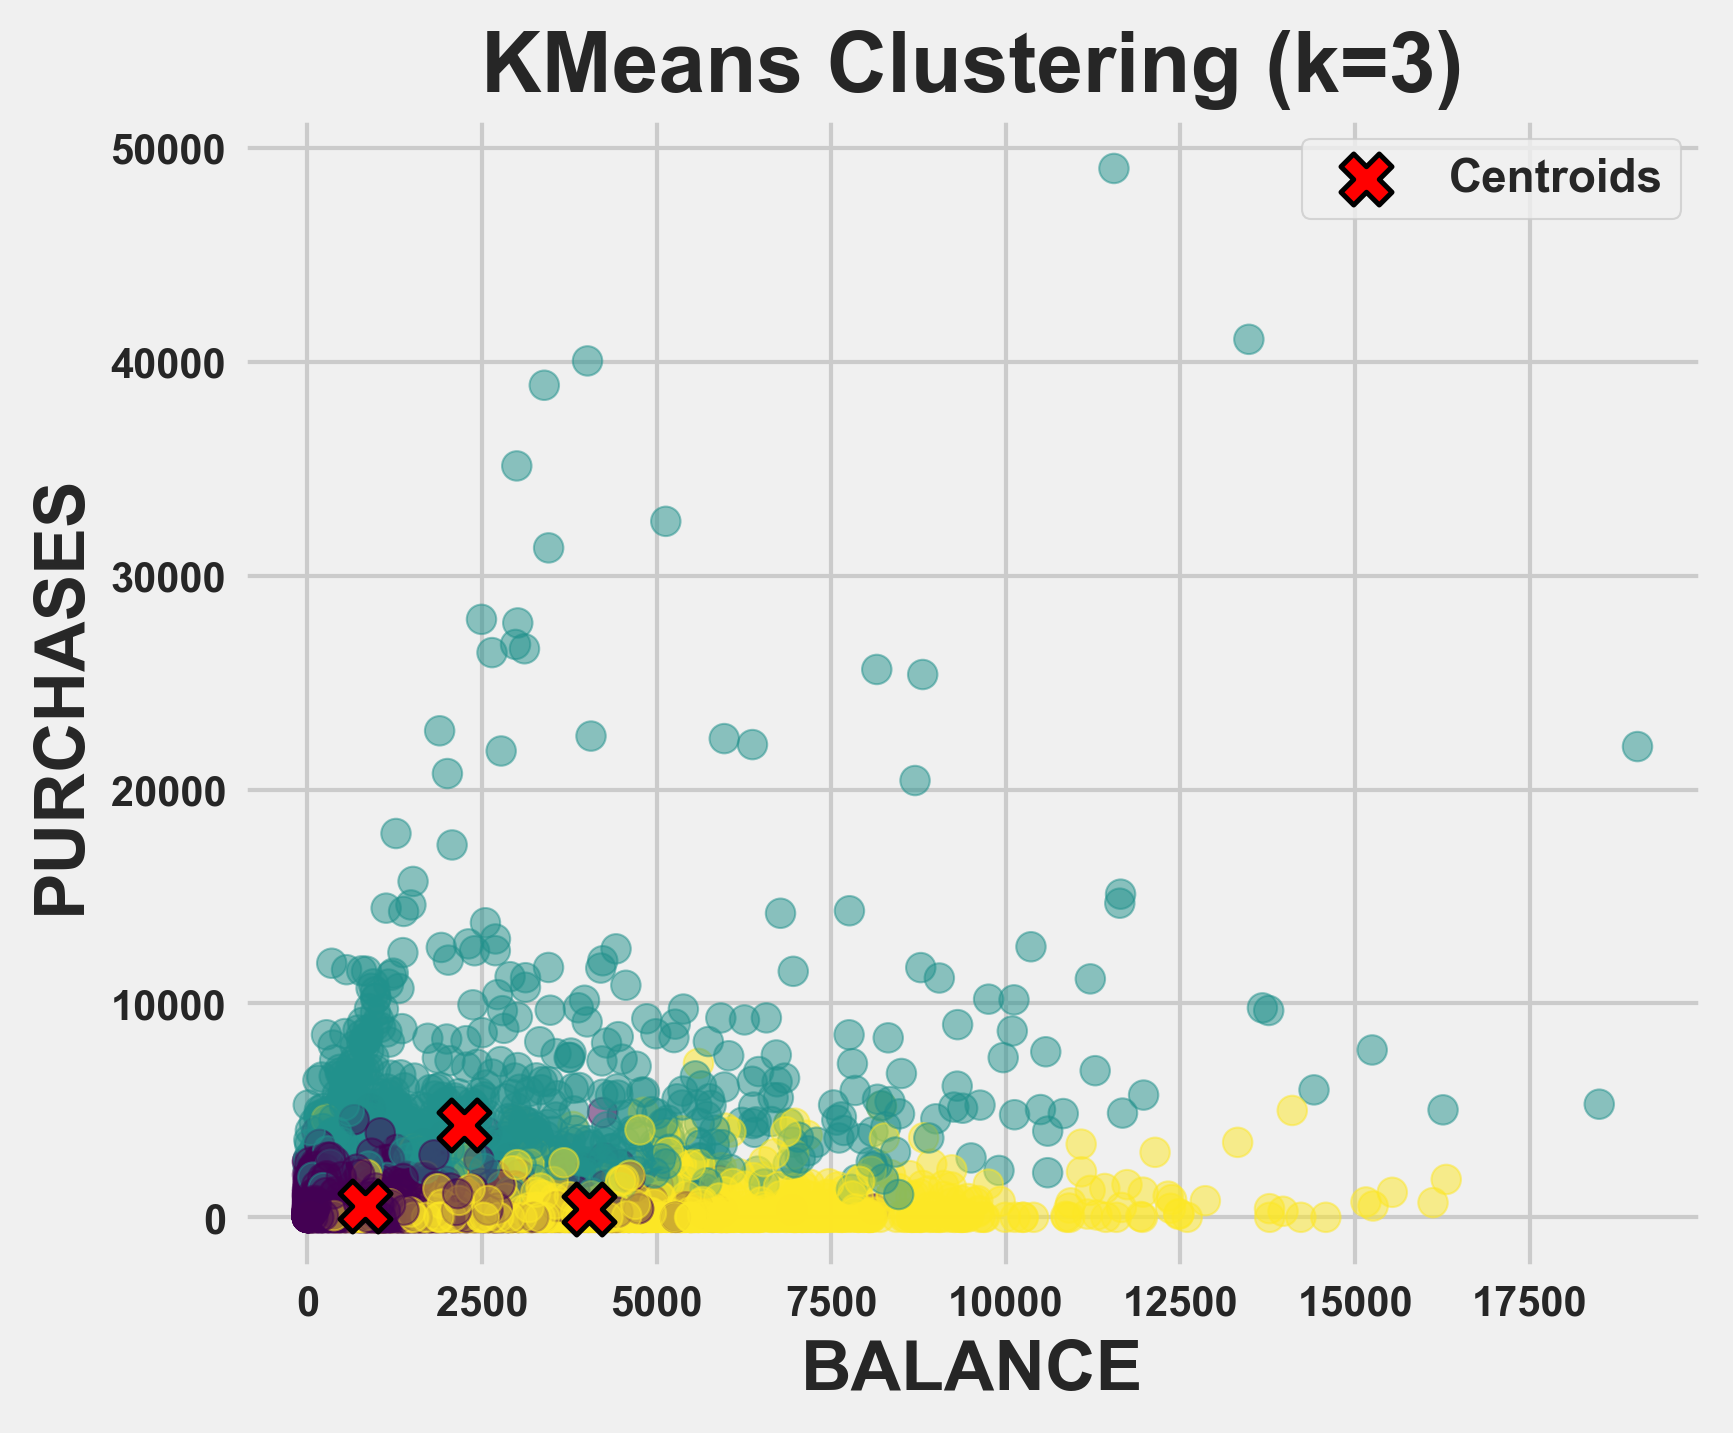

In [185]:
feature_x = "BALANCE"
feature_y = "PURCHASES"

best_k = 3
kmeans_final = KMeans(n_clusters=best_k, **kmeans_set)
kmeans_final.fit(scaled_data)

labels = kmeans_final.labels_          
centroids_scaled = kmeans_final.cluster_centers_  

centroids_original = scaler.inverse_transform(centroids_scaled)

centroids_df = pd.DataFrame(centroids_original, columns=data.columns)

plt.figure(figsize=(6, 5))

plt.scatter(
    data[feature_x],
    data[feature_y],
    c=labels.astype(float),  
    s=50,
    alpha=0.5,
    cmap="viridis"
)

plt.scatter(
    centroids_df[feature_x],
    centroids_df[feature_y],
    c="red",
    s=150,
    marker="X",
    edgecolors="black",
    linewidths=1.2,
    label="Centroids"
)

plt.xlabel(feature_x)
plt.ylabel(feature_y)
plt.title(f"KMeans Clustering (k={best_k})")
plt.legend()
plt.tight_layout()
plt.show()

In [186]:
best_k = 3
kmeans_final = KMeans(n_clusters=best_k, **kmeans_set)
kmeans_final.fit(scaled_data)

data_clusters = data.copy()
data_clusters["cluster"] = kmeans_final.labels_

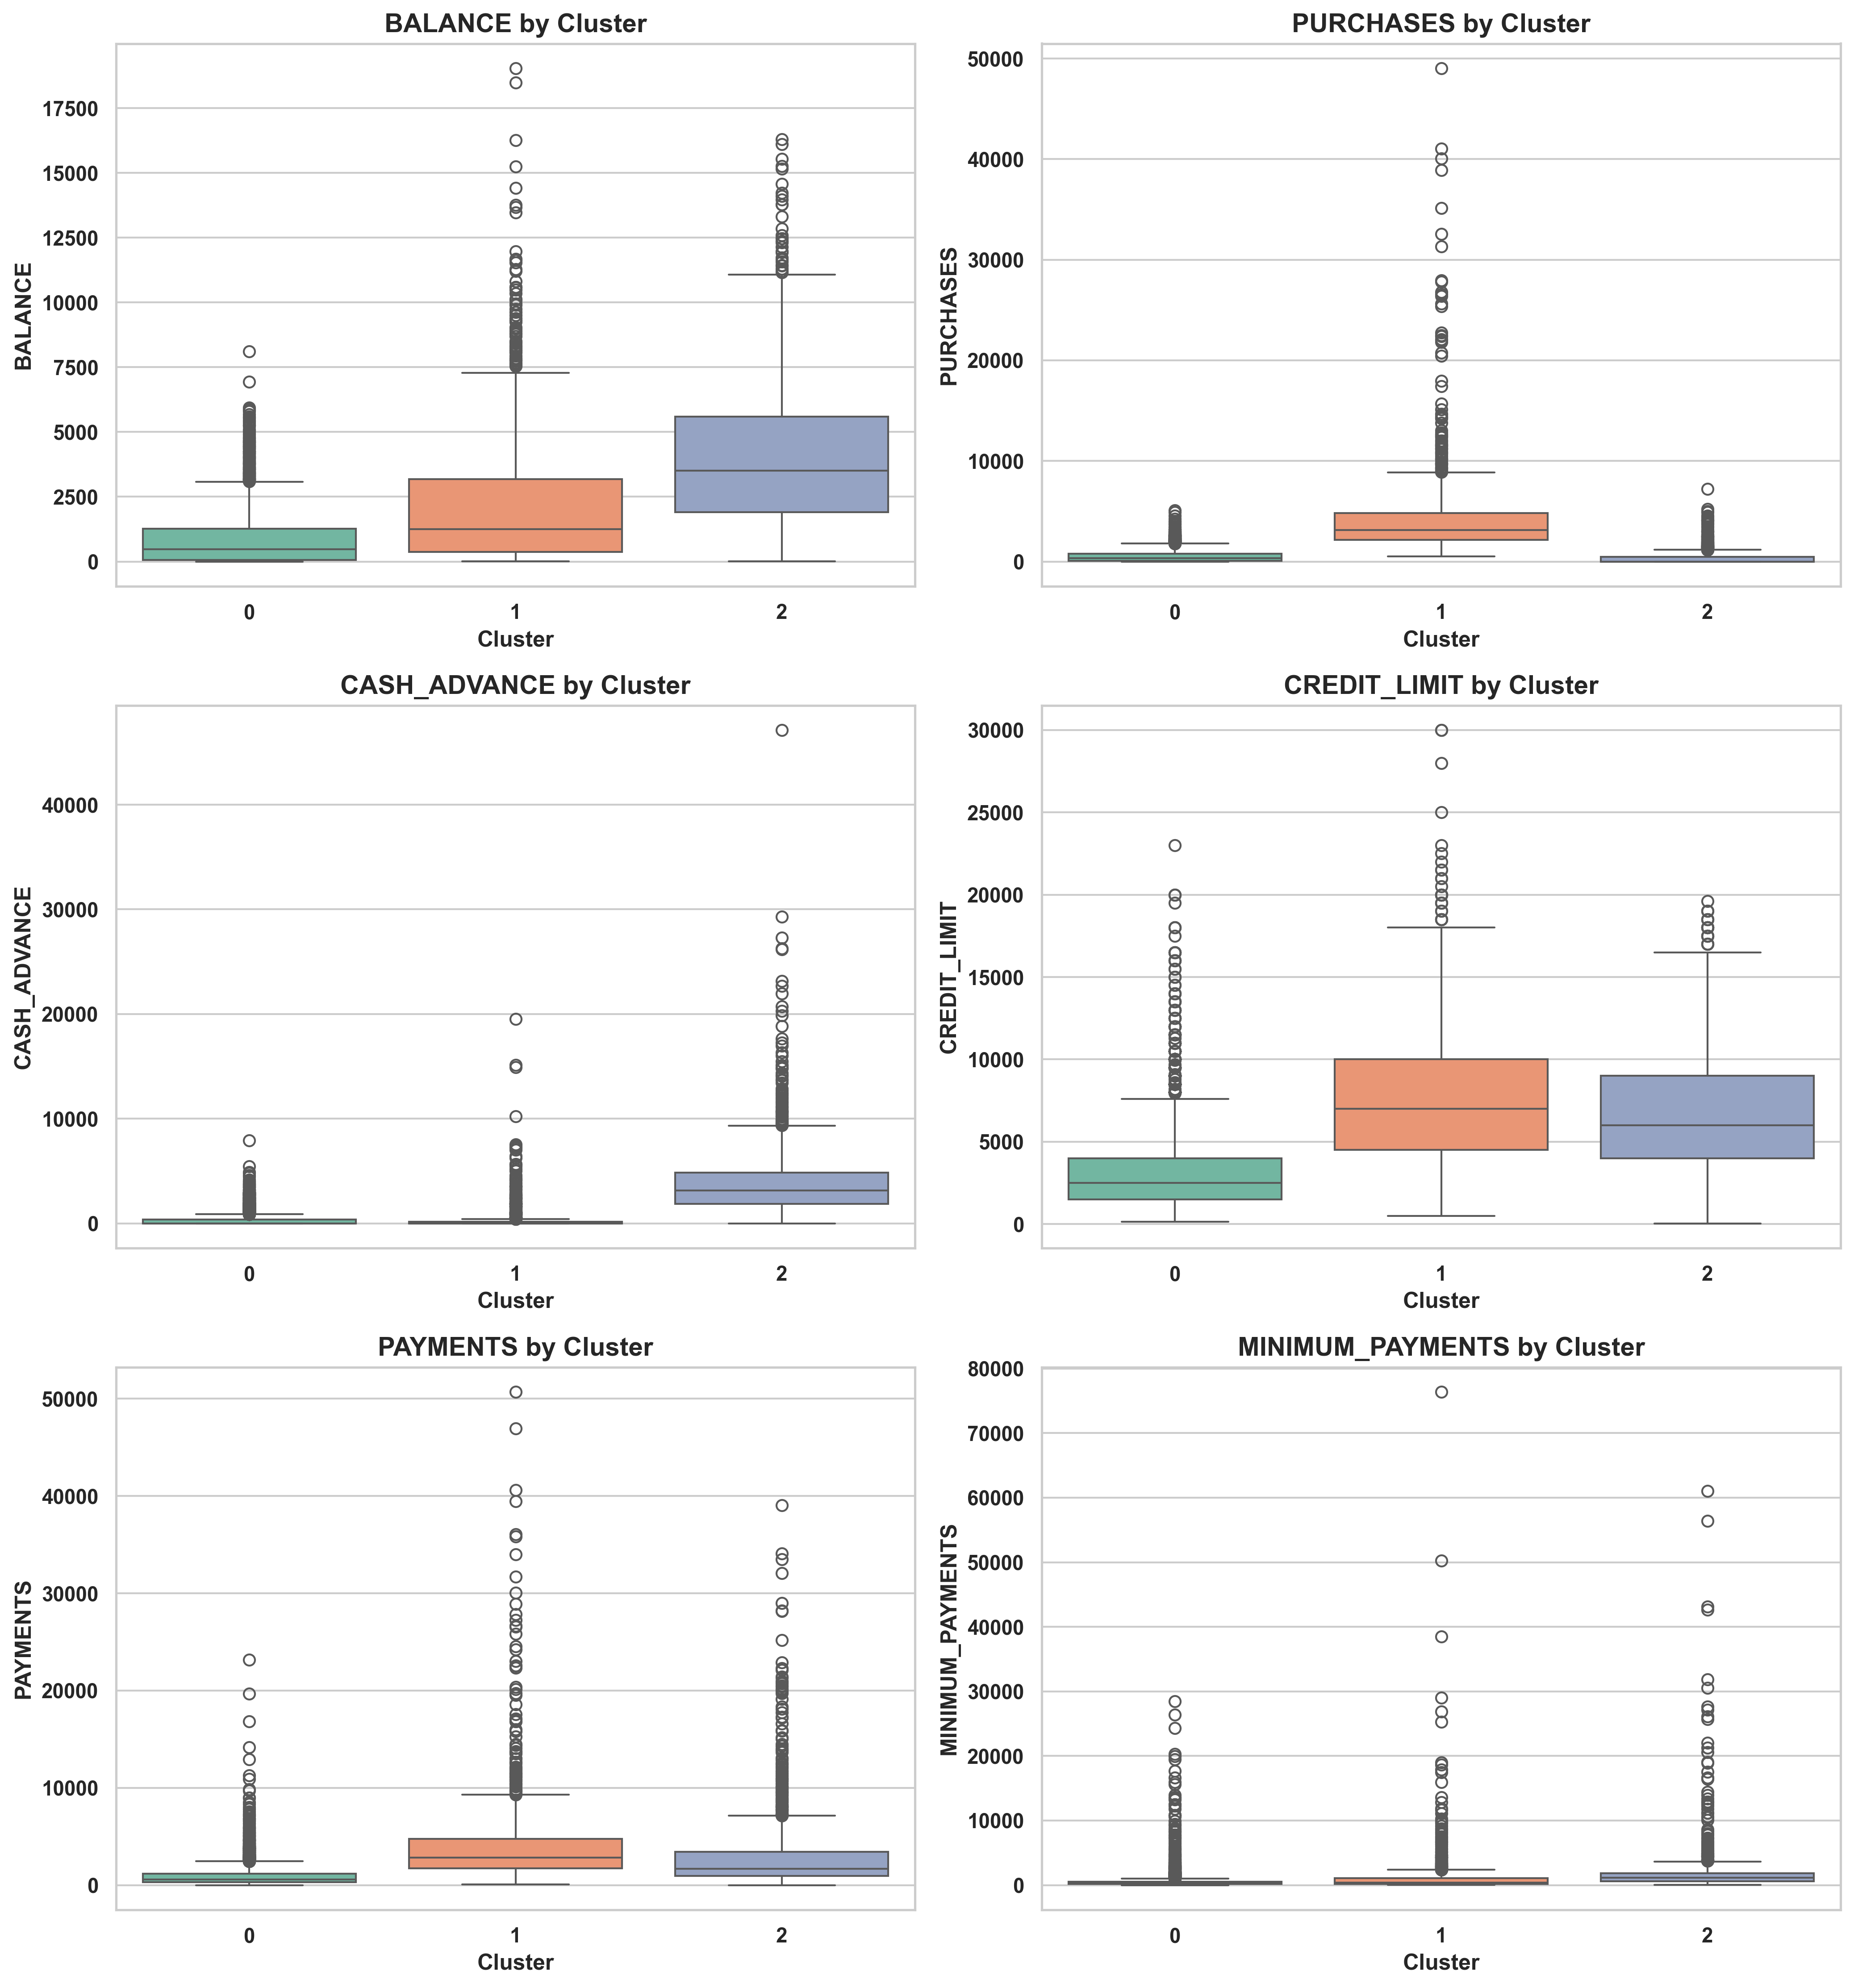

In [187]:
sns.set(style="whitegrid")

features_to_plot = [
    "BALANCE",
    "PURCHASES",
    "CASH_ADVANCE",
    "CREDIT_LIMIT",
    "PAYMENTS",
    "MINIMUM_PAYMENTS"
]

ncols = 2
nrows = (len(features_to_plot) + 1) // ncols

plt.figure(figsize=(14, nrows * 5))

for i, feature in enumerate(features_to_plot, 1):
    plt.subplot(nrows, ncols, i)
    sns.boxplot(
        data=data_clusters,  
        x="cluster",
        y=feature,
        palette="Set2"
    )
    plt.title(f"{feature} by Cluster", fontsize=14, fontweight="bold")
    plt.xlabel("Cluster")
    plt.ylabel(feature)

plt.tight_layout()
plt.show()

Scatterplots were not useful because the financial features are highly skewed with many outliers causing the points to overlap and hide the cluster structure boxplots work better because they clearly show the distribution and differences of each feature across clusters allowing us to interpret customer behavior in each group

In [188]:
df_original = data.copy()          
numeric_cols = df_original.columns 
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_original[numeric_cols])

kmeans_set = {
    "init": "random",
    "n_init": 10,
    "max_iter": 300,
    "random_state": 42
}

df = df_original.copy()
df["cluster"] = 0 

centroids_df = pd.DataFrame(columns=numeric_cols)


root = tk.Tk()
root.title("KMeans Clustering Visualization")

root.geometry("950x700")


controls_frame = ttk.Frame(root)
controls_frame.pack(side=tk.TOP, fill=tk.X, padx=10, pady=5)

feature_x_var = tk.StringVar(value=numeric_cols[0])
feature_y_var = tk.StringVar(value=numeric_cols[1])

ttk.Label(controls_frame, text="X feature:").pack(side=tk.LEFT, padx=5)
x_menu = ttk.Combobox(
    controls_frame,
    textvariable=feature_x_var,
    values=list(numeric_cols),
    width=18,
    state="readonly"
)
x_menu.pack(side=tk.LEFT, padx=5)

ttk.Label(controls_frame, text="Y feature:").pack(side=tk.LEFT, padx=5)
y_menu = ttk.Combobox(
    controls_frame,
    textvariable=feature_y_var,
    values=list(numeric_cols),
    width=18,
    state="readonly"
)
y_menu.pack(side=tk.LEFT, padx=5)

ttk.Label(controls_frame, text="Number of clusters (k):").pack(side=tk.LEFT, padx=10)
k_var = tk.StringVar(value="3")
k_entry = ttk.Entry(controls_frame, textvariable=k_var, width=5)
k_entry.pack(side=tk.LEFT, padx=5)

fig = Figure(figsize=(7, 5), dpi=100)
ax = fig.add_subplot(111)

canvas = FigureCanvasTkAgg(fig, master=root)
canvas_widget = canvas.get_tk_widget()
canvas_widget.pack(side=tk.TOP, fill=tk.BOTH, expand=True, padx=10, pady=10)

def run_kmeans():
    global df, centroids_df

    try:
        k = int(k_var.get())
    except ValueError:
        messagebox.showerror("Invalid k", "Please enter an integer value for k.")
        return

    if k < 2 or k > 15:
        messagebox.showerror("Invalid k", "Please choose k between 2 and 15.")
        return

    kmeans = KMeans(n_clusters=k, **kmeans_set)
    labels = kmeans.fit_predict(scaled_features)

    df["cluster"] = labels

    centroids_scaled = kmeans.cluster_centers_
    centroids = scaler.inverse_transform(centroids_scaled)
    centroids_df = pd.DataFrame(centroids, columns=numeric_cols)

    root.title(f"KMeans Clustering Visualization (k = {k})")

    update_plot()


def update_plot(*args):
    x = feature_x_var.get()
    y = feature_y_var.get()

    ax.clear()

    if x == y:
        ax.text(
            0.5,
            0.5,
            "Select two different features for X and Y.",
            ha="center",
            va="center",
            transform=ax.transAxes
        )
        ax.set_xticks([])
        ax.set_yticks([])
        canvas.draw()
        return

    scatter = ax.scatter(
        df[x],
        df[y],
        c=df["cluster"].astype(float),
        cmap="viridis",
        s=20,
        alpha=0.6
    )
    if not centroids_df.empty:
        ax.scatter(
            centroids_df[x],
            centroids_df[y],
            c="red",
            s=150,
            marker="X",
            edgecolors="black",
            linewidths=1.2,
            label="Centroids"
        )
        ax.legend(loc="best")

    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title("KMeans Clusters")

    canvas.draw()

process_button = tk.Button(
    root,
    text="Process K-Means",
    command=run_kmeans,
    bg="brown",
    fg="white"
)
process_button.pack(side=tk.TOP, padx=10, pady=5)

feature_x_var.trace_add("write", update_plot)
feature_y_var.trace_add("write", update_plot)

run_kmeans()

root.mainloop()

In [189]:
gmm_results = []
k_values_gmm = range(2, 11)  

for k in k_values_gmm:
    gmm = GaussianMixture(
        n_components=k,
        covariance_type="full",
        random_state=42
    )
    gmm.fit(scaled_data)
    
    labels = gmm.predict(scaled_data)
    sil = silhouette_score(scaled_data, labels)
    bic = gmm.bic(scaled_data)
    
    gmm_results.append({
        "n_components": k,
        "bic": bic,
        "silhouette": sil
    })

df_gmm = pd.DataFrame(gmm_results)
df_gmm

,n_components,bic,silhouette
0,2,133617.468239,0.193967
1,3,-103587.752412,0.115123
2,4,-129691.946620,0.098180
3,5,-138504.762194,0.067663
4,6,-223708.795626,0.054583
5,7,-259572.088177,0.037191
6,8,-289023.945070,0.035897
7,9,-319321.224487,0.028798
8,10,-329114.504369,0.023331


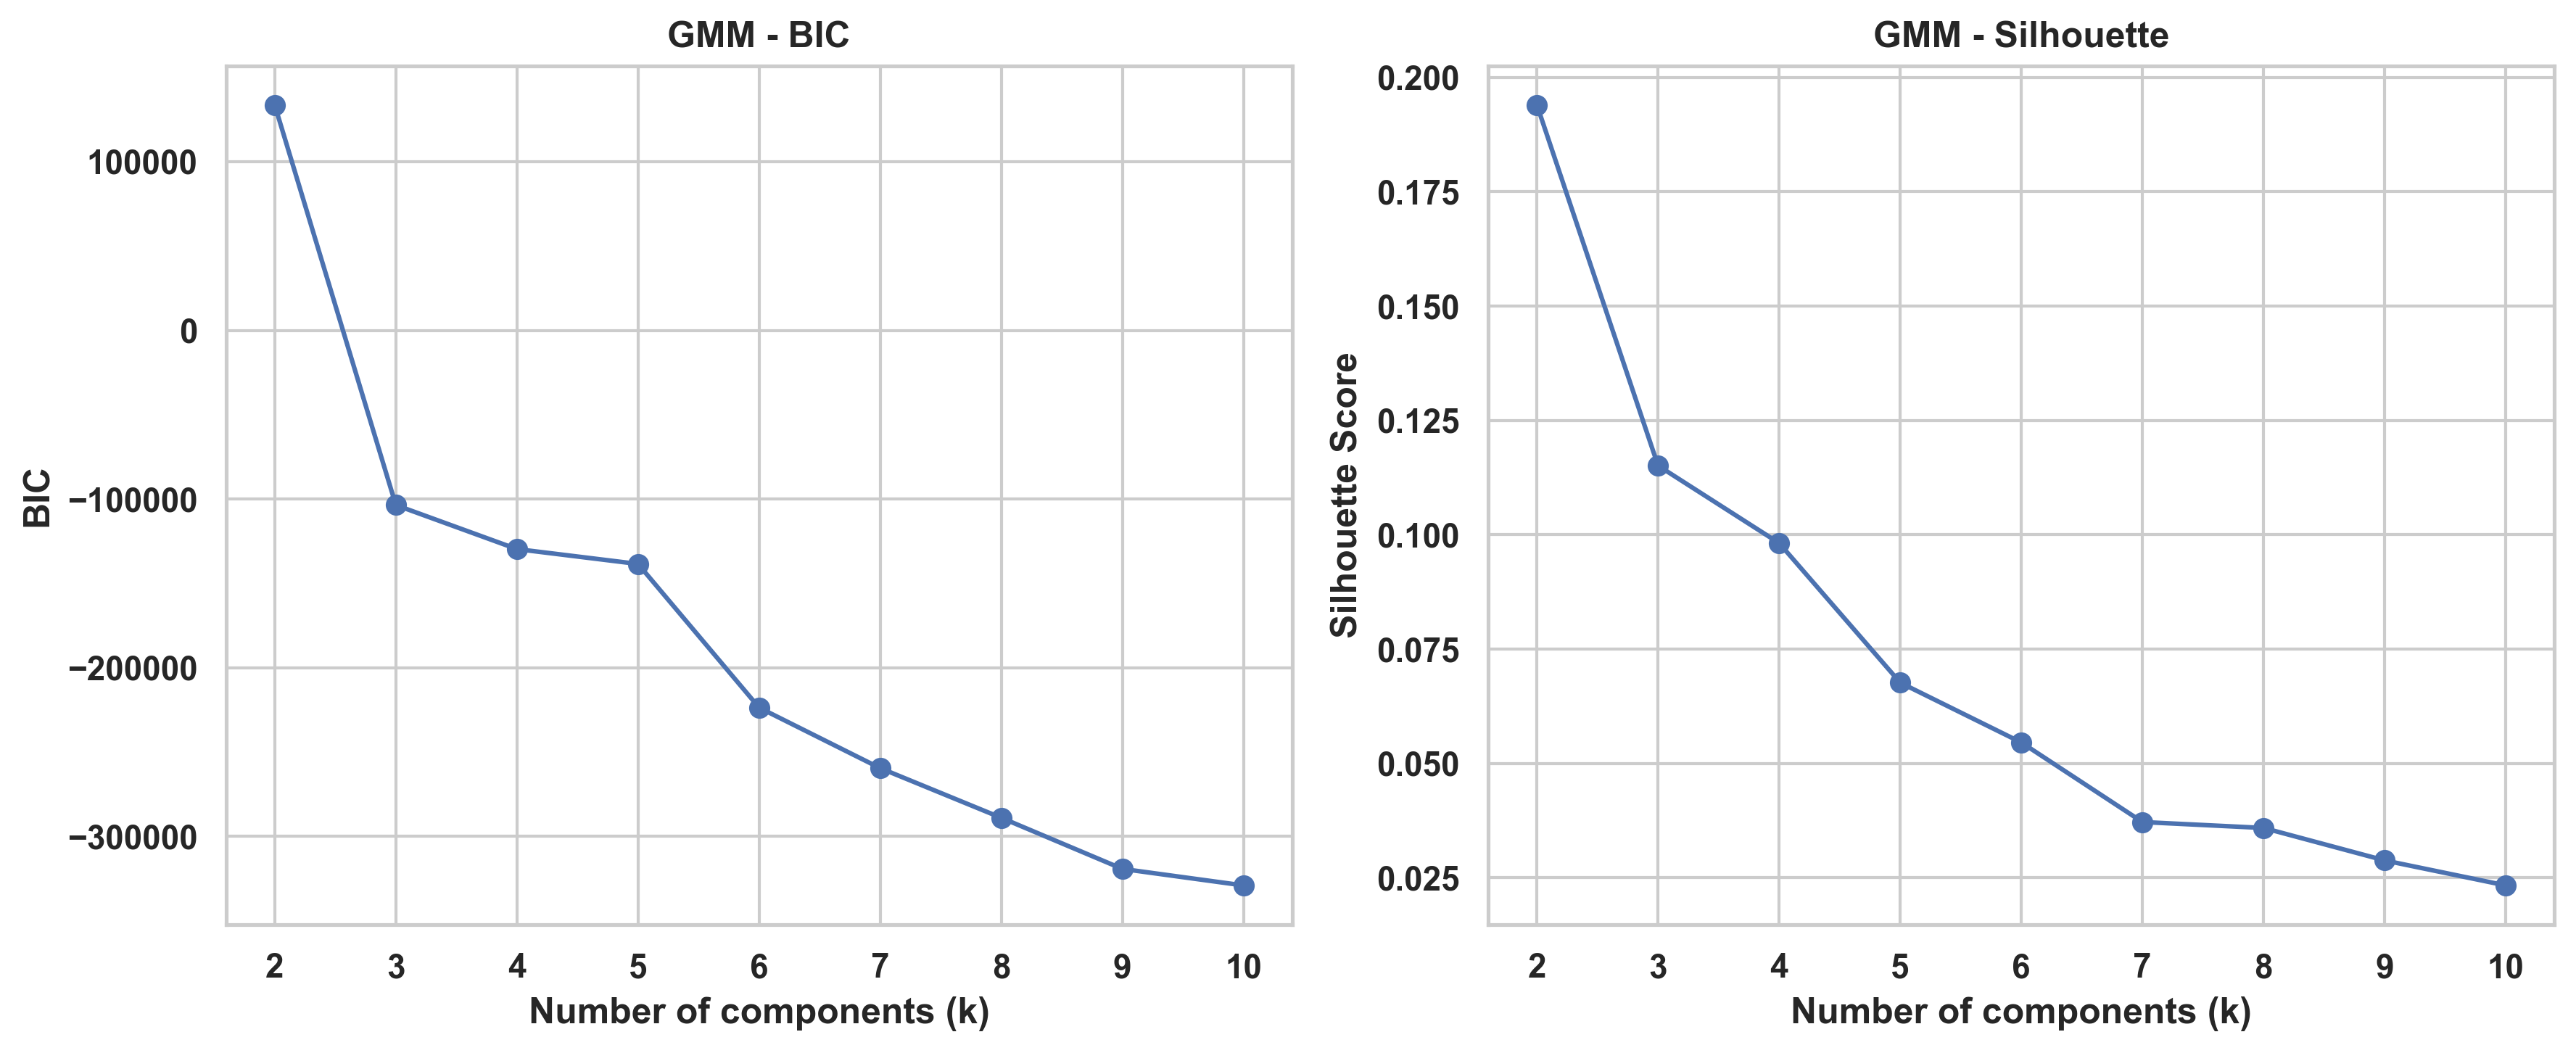

In [190]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(df_gmm["n_components"], df_gmm["bic"], marker="o")
plt.xticks(df_gmm["n_components"])
plt.xlabel("Number of components (k)")
plt.ylabel("BIC")
plt.title("GMM - BIC")

plt.subplot(1,2,2)
plt.plot(df_gmm["n_components"], df_gmm["silhouette"], marker="o")
plt.xticks(df_gmm["n_components"])
plt.xlabel("Number of components (k)")
plt.ylabel("Silhouette Score")
plt.title("GMM - Silhouette")

plt.tight_layout()
plt.show()

In [191]:
best_idx_gmm = df_gmm["silhouette"].idxmax()

def highlight_best_row_gmm(row):
    return ["background-color: orange" if row.name == best_idx_gmm else "" 
            for _ in row]

df_gmm_style = df_gmm.style.apply(highlight_best_row_gmm, axis=1)
df_gmm_style

,n_components,bic,silhouette
0,2,133617.468239,0.193967
1,3,-103587.752412,0.115123
2,4,-129691.946620,0.098180
3,5,-138504.762194,0.067663
4,6,-223708.795626,0.054583
5,7,-259572.088177,0.037191
6,8,-289023.945070,0.035897
7,9,-319321.224487,0.028798
8,10,-329114.504369,0.023331


GMM was also tested but it produced significantly lower silhouette scores compared to KMeans This indicates that the data does not follow Gaussian distributions and therefore KMeans provides more meaningful customer groups

In [192]:
dbscan_results = []

eps_values = [0.4, 0.6, 0.8, 1.0, 1.2]      
min_samples_values = [5, 10, 20]

for eps in eps_values:
    for m in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=m)
        labels = db.fit_predict(scaled_features)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = np.sum(labels == -1)

        sil = np.nan
        core_mask = labels != -1
        if n_clusters >= 2 and core_mask.sum() > 0:
            sil = silhouette_score(
                scaled_features[core_mask],
                labels[core_mask]
            )

        dbscan_results.append({
            "eps": eps,
            "min_samples": m,
            "n_clusters": n_clusters,
            "n_noise": n_noise,
            "silhouette": sil
        })

df_dbscan = pd.DataFrame(dbscan_results)
df_dbscan

,eps,min_samples,n_clusters,n_noise,silhouette
0,0.4,5,33,7227,0.111723
1,0.4,10,15,7621,0.214557
2,0.4,20,6,8002,0.343171
3,0.6,5,38,5650,-0.445905
4,0.6,10,8,6331,-0.181846
5,0.6,20,2,6830,0.434016
6,0.8,5,16,4335,-0.169440
7,0.8,10,8,4830,-0.085451
8,0.8,20,2,5391,0.291925
9,1.0,5,19,3051,-0.142950


In [193]:
valid_mask = df_dbscan["silhouette"].notna()

if valid_mask.any():
    best_idx_db = df_dbscan.loc[valid_mask, "silhouette"].idxmax()
else:
    best_idx_db = None

def highlight_best_row_db(row):
    if best_idx_db is not None and row.name == best_idx_db:
        return ["background-color: orange" for _ in row]
    return ["" for _ in row]

df_dbscan_style = df_dbscan.style.apply(highlight_best_row_db, axis=1)
df_dbscan_style

,eps,min_samples,n_clusters,n_noise,silhouette
0,0.400000,5,33,7227,0.111723
1,0.400000,10,15,7621,0.214557
2,0.400000,20,6,8002,0.343171
3,0.600000,5,38,5650,-0.445905
4,0.600000,10,8,6331,-0.181846
5,0.600000,20,2,6830,0.434016
6,0.800000,5,16,4335,-0.169440
7,0.800000,10,8,4830,-0.085451
8,0.800000,20,2,5391,0.291925
9,1.000000,5,19,3051,-0.142950


In [194]:
n_clusters_final = len(set(labels_db)) - (1 if -1 in labels_db else 0)
print("Number of real clusters:", n_clusters_final)

n_noise_final = list(labels_db).count(-1)
print("Noise points:", n_noise_final)

Number of real clusters: 2
Noise points: 6830


DBSCAN (eps = 0.6, min_samples = 20) produced the highest silhouette score (0.434) detecting 2 clusters and over 6800 noise points this shows many irregular behaviors in the dataset so DBSCAN is mainly useful for identifying anomalies rather than defining customer segments

In [195]:
kmeans_final = KMeans(
    n_clusters=3,
    init="random",
    n_init=10,
    max_iter=300,
    random_state=42
)

labels_km = kmeans_final.fit_predict(scaled_features)
data["cluster_kmeans"] = labels_km

In [196]:
gmm_final = GaussianMixture(
    n_components=2,
    covariance_type="full",
    random_state=42
)

labels_gmm = gmm_final.fit_predict(scaled_features)
data["cluster_gmm"] = labels_gmm

In [197]:
dbscan_final = DBSCAN(
    eps=0.6,
    min_samples=20
)

labels_dbscan = dbscan_final.fit_predict(scaled_features)
data["cluster_dbscan"] = labels_dbscan

In [198]:
data

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,cluster_kmeans,cluster_gmm,cluster_dbscan
0,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,0,1,-1
1,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,2,1,-1
2,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,0,0,-1
4,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,0,1,0
5,1809.828751,1.000000,1333.28,0.00,1333.28,0.000000,0.666667,0.000000,0.583333,0.000000,0,8,1800.0,1400.057770,2407.246035,0.000000,12,0,0,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8943,5.871712,0.500000,20.90,20.90,0.00,0.000000,0.166667,0.166667,0.000000,0.000000,0,1,500.0,58.644883,43.473717,0.000000,6,0,1,-1
8945,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.500000,6,0,1,-1
8947,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.250000,6,0,1,-1
8948,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.250000,6,0,1,-1


KMeans produced the clearest segmentation with 3 meaningful clusters
GMM formed 2 weaker clusters with lower separation
DBSCAN identified many noises (over 6800 noise points) and is useful mainly for outlier detection not segmentation

In [199]:
data["CUST_ID"] = customer_id.values

In [200]:
data = data[["CUST_ID"] + [col for col in data.columns if col != "CUST_ID"]]

In [201]:
data

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,...,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,cluster_kmeans,cluster_gmm,cluster_dbscan
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,...,0,2,1000.0,201.802084,139.509787,0.000000,12,0,1,-1
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,...,4,0,7000.0,4103.032597,1072.340217,0.222222,12,2,1,-1
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,...,0,12,7500.0,622.066742,627.284787,0.000000,12,0,0,-1
4,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,...,0,1,1200.0,678.334763,244.791237,0.000000,12,0,1,0
5,C10006,1809.828751,1.000000,1333.28,0.00,1333.28,0.000000,0.666667,0.000000,0.583333,...,0,8,1800.0,1400.057770,2407.246035,0.000000,12,0,0,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8943,C19184,5.871712,0.500000,20.90,20.90,0.00,0.000000,0.166667,0.166667,0.000000,...,0,1,500.0,58.644883,43.473717,0.000000,6,0,1,-1
8945,C19186,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,...,0,6,1000.0,325.594462,48.886365,0.500000,6,0,1,-1
8947,C19188,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,...,0,5,1000.0,81.270775,82.418369,0.250000,6,0,1,-1
8948,C19189,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,...,2,0,500.0,52.549959,55.755628,0.250000,6,0,1,-1


Removed CUST_ID during preprocessing because it is only an identifier and should not influence the clustering but fter completing the clustering added CUST_ID back so each cluster can be linked to the original custome